In [88]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import skew, kurtosis, norm
from scipy.stats import gaussian_kde

In [25]:
rows = []
for f in Path(".").glob("*.parquet"):
    name = f.name
    if "_pnl" in name:
        continue
    if "features" in name:
        continue
    if "sign" not in name and "logreg" not in name:
        continue
    horizon = int(re.search(r"_(\d+)\.parquet$", name).group(1))
    model = "logreg" if "logreg" in name else "xgb
    df = pd.read_parquet(f)
    mcc = matthews_corrcoef(
        df["Y_true"],
        df["Y_pred"])
    rows.append({
        "model": model,
        "horizon": horizon,
        "mcc": mcc})
results = pd.DataFrame(rows)

In [29]:
(results
    .groupby(["model", "horizon"])["mcc"]
    .agg(["mean", "std", "count"])
    .round(4))

mean     std  count
model  horizon                       
logreg 3       -0.0045  0.0203      5
       5       -0.0175  0.0346      5
       10      -0.0292  0.0444      5
       30      -0.0165  0.0918      5
       60      -0.0418  0.0645      5
xgb    3        0.0206  0.0305      5
       5        0.0234  0.0340      5
       10       0.0109  0.0345      5
       30      -0.0313  0.0737      5
       60       0.0099  0.1533      5

In [33]:
labels = [-1, 0, 1]
cms = {}
for f in Path(".").glob("*.parquet"):
    name = f.name
    if "_pnl" in name:
        continue
    if "features" in name:
        continue
    if "sign" not in name and "logreg" not in name:
        continue
    horizon = int(re.search(r"_(\d+)\.parquet$", name).group(1))
    model = "logreg" if "logreg" in name else "xgb"
    df = pd.read_parquet(f)
    if model == "xgb":
        mapping = {0: -1, 1: 0, 2: 1}
        y_true = df["Y_true"].map(mapping)
        y_pred = df["Y_pred"].map(mapping)
    else:
        y_true = df["Y_true"]
        y_pred = df["Y_pred"]
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels)
    key = (model, horizon)
    if key not in cms:
        cms[key] = cm
    else:
        cms[key] += cm

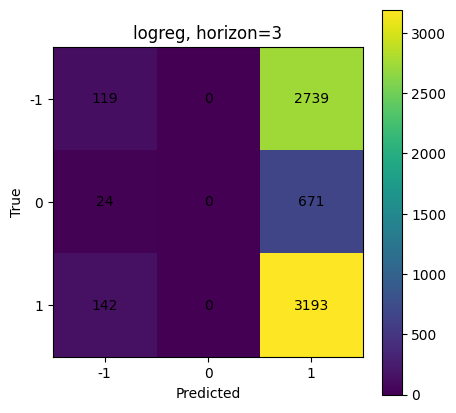

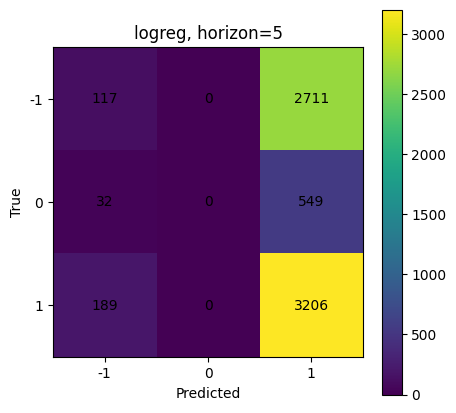

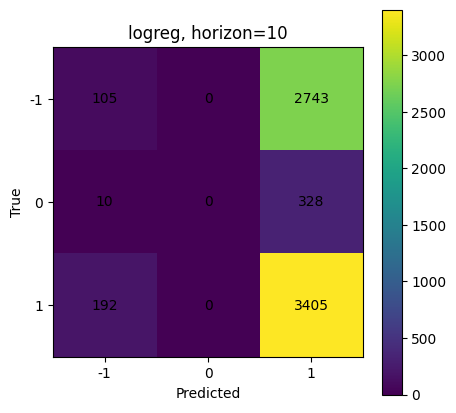

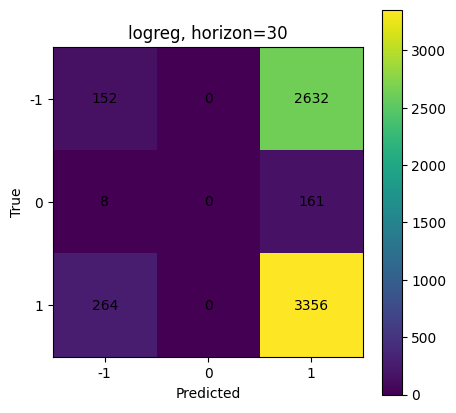

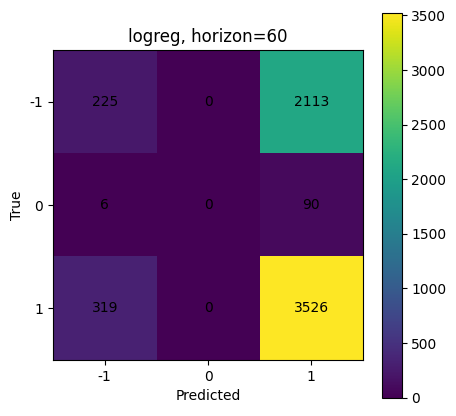

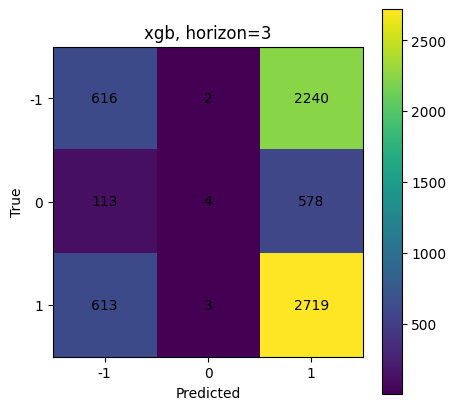

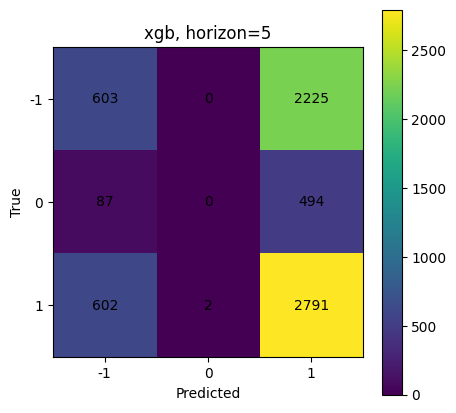

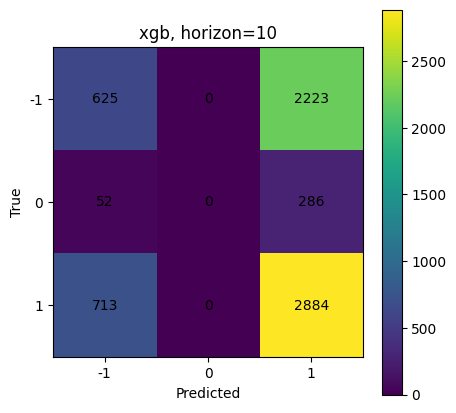

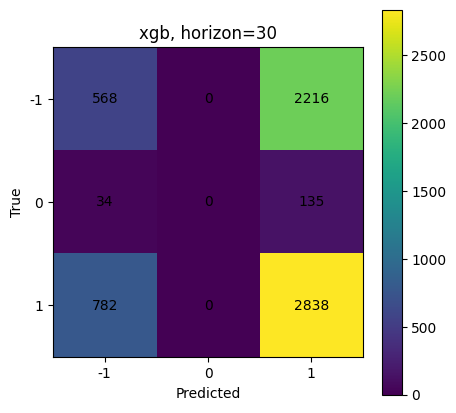

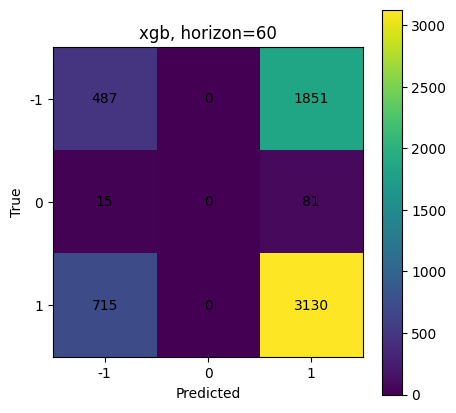

In [34]:
for (model, horizon), cm in sorted(cms.items()):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm)
    plt.title(f"{model}, horizon={horizon}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

In [35]:
metric_rows = []
for (model, horizon), cm in cms.items():
    for label, side in [(-1, "short"), (1, "long")]:
        idx = labels.index(label)
        tp = cm[idx, idx]
        fn = cm[idx, :].sum() - tp
        fp = cm[:, idx].sum() - tp
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0)
        metric_rows.append({
            "model": model,
            "horizon": horizon,
            "side": side,
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": cm[idx, :].sum()})
metrics = pd.DataFrame(metric_rows)

In [38]:
metrics.pivot_table(
    index=["model", "horizon"],
    columns="side",
    values="f1"
).round(4)

side              long   short
model  horizon                
logreg 3        0.6426  0.0757
       5        0.6502  0.0739
       10       0.6761  0.0666
       30       0.6871  0.0948
       60       0.7366  0.1558
xgb    3        0.6129  0.2933
       5        0.6268  0.2927
       10       0.6416  0.2950
       30       0.6443  0.2726
       60       0.7028  0.2740

In [37]:
metrics.pivot_table(
    index=["model", "horizon"],
    columns="side",
    values="recall"
).round(4)

side              long   short
model  horizon                
logreg 3        0.9574  0.0416
       5        0.9443  0.0414
       10       0.9466  0.0369
       30       0.9271  0.0546
       60       0.9170  0.0962
xgb    3        0.8153  0.2155
       5        0.8221  0.2132
       10       0.8018  0.2195
       30       0.7840  0.2040
       60       0.8140  0.2083

In [ ]:
groups = defaultdict(list)
for f in Path(".").glob("*.parquet"):
    if "_pnl" in f.name or "features" in f.name:
        continue
    match = re.search(
        r"_(xgb|ridge|logreg)(?:_[a-z]+)?_(\d+)\.parquet$",
        f.name)
    if match:
        model = match.group(1)
        horizon = int(match.group(2))
        groups[(model, horizon)].append(f)

In [40]:
groups = defaultdict(list)
for f in Path(".").glob("*.parquet"):
    if "_pnl" in f.name or "features" in f.name:
        continue
    if "xgb_regression" not in f.name and "ridge" not in f.name:
        continue
    horizon = int(re.search(r"_(\d+)\.parquet$", f.name).group(1))
    model = "xgb_regression" if "xgb_regression" in f.name else "ridge"
    groups[(model, horizon)].append(pd.read_parquet(f))

In [41]:
dfs = {
    key: pd.concat(dfs, ignore_index=True)
    for key, dfs in groups.items()}

In [43]:
def hac_se(d, lag):
    d = np.asarray(d)
    T = len(d)
    d = d - d.mean()
    gamma0 = np.dot(d, d) / T
    s = gamma0
    for k in range(1, lag + 1):
        gamma = np.dot(d[k:], d[:-k]) / T
        weight = 1 - k / (lag + 1)  
        s += 2 * weight * gamma
    return np.sqrt(s / T)

In [44]:
def dm_test(y, pred1, pred2, lag):
    e1 = (y - pred1) ** 2
    e2 = (y - pred2) ** 2
    d = e1 - e2
    dm_stat = d.mean() / hac_se(d, lag)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

In [46]:
dm_rows = []
for h in [3, 5, 10, 30, 60]:
    xgb = dfs[("xgb_regression", h)]
    ridge = dfs[("ridge", h)]
    dm_stat, p_value = dm_test(
        xgb["Y_true"].values,
        xgb["Y_pred"].values,
        ridge["Y_pred"].values,
        lag=h)
    dm_rows.append({
        "horizon": h,
        "dm_stat": dm_stat,
        "p_value": p_value})
dm_results = pd.DataFrame(dm_rows)

In [50]:
dm_results["5pct"] = dm_results["p_value"] < 0.05
dm_results.round(4)

,horizon,dm_stat,p_value,significant_5pct,5pct
0,3,1.3728,0.1698,False,False
1,5,1.5184,0.1289,False,False
2,10,1.7991,0.0720,False,False
3,30,3.3954,0.0007,True,True
4,60,1.2271,0.2198,False,False


In [61]:
pnl_by_horizon = {}
start_date = pd.Timestamp("2023-11-30")
for h in [3, 5, 10, 30, 60]:
    pnl_df = None
    for f in Path(".").glob(f"*_{h}_pnl.parquet"):
        col_name = re.search(
            r"^(.+?)_(\d+)_pnl\.parquet$",
            f.name).group(1)
        df = pd.read_parquet(f).reset_index()
        tmp = df[["Date", "ret"]].rename(
            columns={"ret": col_name})
        if pnl_df is None:
            pnl_df = tmp
        else:
            pnl_df = pnl_df.merge(
                tmp,
                on="Date",
                how="outer")
    pnl_df = (
        pnl_df
        .sort_values("Date")
        .query("Date >= @start_date")
        .fillna(0))
    pnl_by_horizon[h] = pnl_df
    pnl_df.to_parquet(
        f"pnl_horizon_{h}.parquet",
        index=False)

In [64]:
d = pd.read_parquet('pnl_horizon_3.parquet')
d.tail(50)

,Date,spx_xgb_regression,qqq_xgb_sign,qqq_logreg,btc_xgb_regression,spx_logreg,qqq_xgb_regression,apple_xgb_regression,apple_xgb_sign,spx_xgb_sign,...,qqq_ridge,btc_ridge,tesla_xgb_regression,btc_logreg,spx_ridge,tesla_xgb_sign,btc_xgb_sign,tesla_ridge,apple_logreg,tesla_logreg
862,2026-04-10,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,...,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0
863,2026-04-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864,2026-04-12,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0
865,2026-04-13,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0
866,2026-04-14,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,...,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0
867,2026-04-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
868,2026-04-16,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,...,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0
869,2026-04-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
870,2026-04-18,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0
871,2026-04-19,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [66]:
def probabilistic_sharpe_ratio(returns, sr_benchmark=0):
    r = pd.Series(returns).dropna()
    T = len(r)
    sr = r.mean() / r.std(ddof=1)
    sk = skew(r, bias=False)
    kt = kurtosis(r, fisher=False, bias=False)
    z = (
        (sr - sr_benchmark)
        * np.sqrt(T - 1)
        / np.sqrt(
            1 - sk * sr + ((kt - 1) / 4) * sr**2))
    psr = norm.cdf(z)
    return sr, psr

In [67]:
rows = []
for h in [3, 5, 10, 30, 60]:
    df = pd.read_parquet(f"pnl_horizon_{h}.parquet")
    pnl_cols = [c for c in df.columns if c != "Date"]
    for col in pnl_cols:
        sr, psr = probabilistic_sharpe_ratio(
            df[col],
            sr_benchmark=0)
        rows.append({
            "horizon": h,
            "strategy": col,
            "sr_daily": sr,
            "sr_ann": sr * np.sqrt(252),
            "psr": psr})
psr_results = pd.DataFrame(rows)

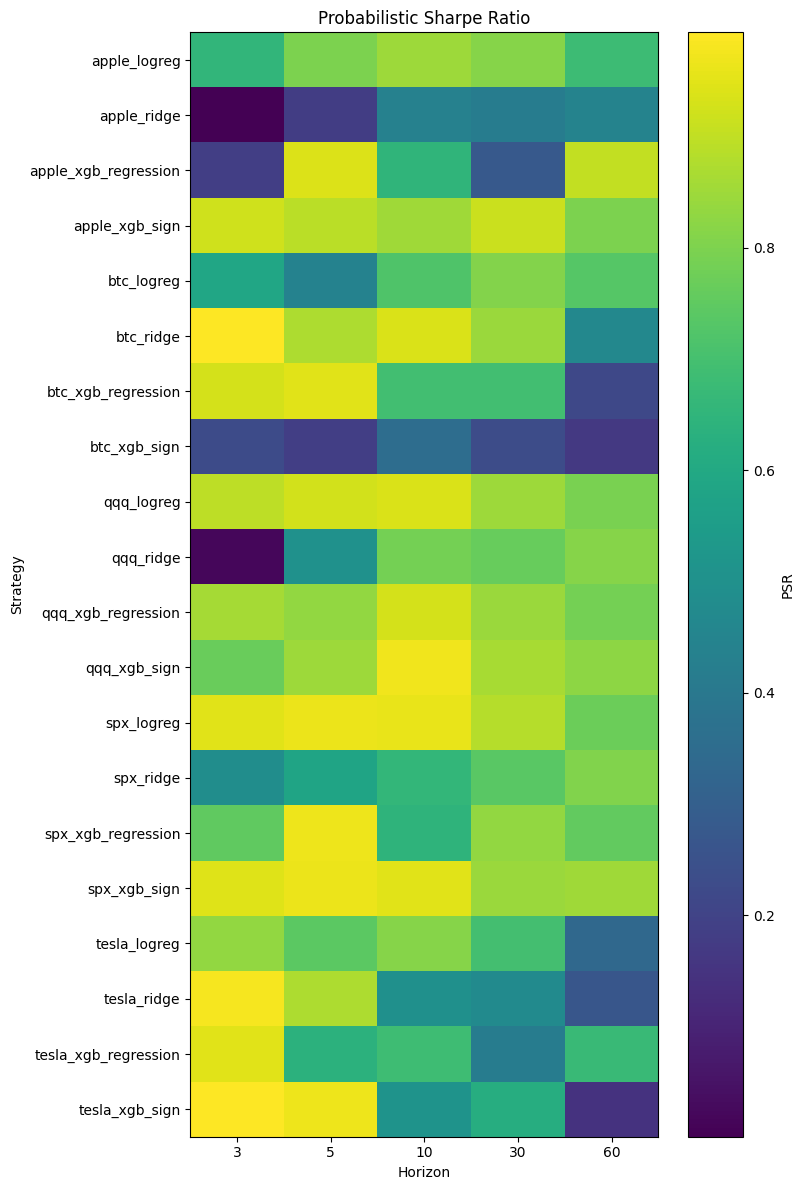

In [70]:
psr_matrix = psr_results.pivot(
    index="strategy",
    columns="horizon",
    values="psr")
plt.figure(figsize=(8, 12))
plt.imshow(psr_matrix, aspect="auto")
plt.xticks(
    range(len(psr_matrix.columns)),
    psr_matrix.columns)
plt.yticks(
    range(len(psr_matrix.index)),
    psr_matrix.index)
plt.colorbar(label="PSR")
plt.xlabel("Horizon")
plt.ylabel("Strategy")
plt.title("Probabilistic Sharpe Ratio")
plt.tight_layout()
plt.show()

In [72]:
rows = []
for h in [3, 5, 10, 30, 60]:
    df = pd.read_parquet(f"pnl_horizon_{h}.parquet")
    pnl_cols = [c for c in df.columns if c != "Date"]
    for col in pnl_cols:
        r = df[col].dropna()
        sr, psr = probabilistic_sharpe_ratio(r)
        rows.append({
            "horizon": h,
            "strategy": col,
            "T": len(r),
            "sr_daily": sr,
            "sr_ann": sr * np.sqrt(252),
            "skew": skew(r, bias=False),
            "kurtosis": kurtosis(r, fisher=False, bias=False),
            "psr": psr})
psr_results = pd.DataFrame(rows)

In [75]:
gamma = 0.5772156649
n_trials = 30 
sr_star = (
    (1 - gamma) * norm.ppf(1 - 1 / n_trials)
    + gamma * norm.ppf(1 - 1 / (n_trials * np.e)))
tmp = psr_results.copy()
tmp["z"] = (
    (tmp["sr_daily"] - sr_star / np.sqrt(tmp["T"] - 1))
    * np.sqrt(tmp["T"] - 1)
    / np.sqrt(
        1
        - tmp["skew"] * tmp["sr_daily"]
        + ((tmp["kurtosis"] - 1) / 4) * tmp["sr_daily"]**2))
tmp["dsr"] = norm.cdf(tmp["z"])
dsr_results = tmp

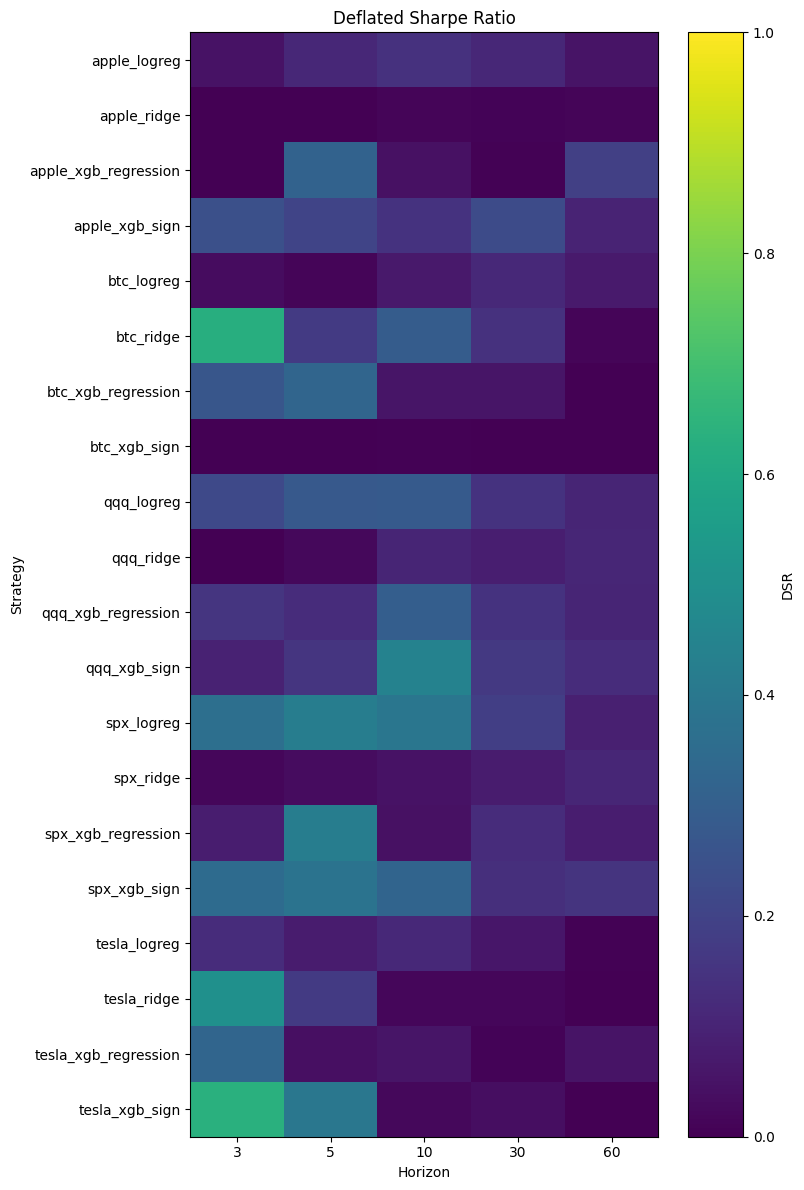

In [76]:
dsr_matrix = dsr_results.pivot(
    index="strategy",
    columns="horizon",
    values="dsr")
plt.figure(figsize=(8, 12))
im = plt.imshow(
    dsr_matrix,
    aspect="auto",
    vmin=0,
    vmax=1)
plt.xticks(range(len(dsr_matrix.columns)), dsr_matrix.columns)
plt.yticks(range(len(dsr_matrix.index)), dsr_matrix.index)
plt.colorbar(im, label="DSR")
plt.xlabel("Horizon")
plt.ylabel("Strategy")
plt.title("Deflated Sharpe Ratio")
plt.tight_layout()
plt.show()

In [79]:
def stationary_bootstrap_indices(T, p, B):
    idx = np.empty((B, T), dtype=int)
    for b in range(B):
        idx[b, 0] = np.random.randint(T)
        for t in range(1, T):
            if np.random.rand() < p:
                idx[b, t] = np.random.randint(T)
            else:
                idx[b, t] = (idx[b, t-1] + 1) % T
    return idx
def spa_test(returns_df, B=3000, block_len=10):
    X = returns_df.values
    X = X - 0.0  
    T, N = X.shape
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=1)
    t_stats = np.sqrt(T) * mu / sigma
    spa_stat = np.max(t_stats)
    X_centered = X - mu
    p = 1 / block_len
    boot_idx = stationary_bootstrap_indices(T, p, B)
    boot_stats = []
    for b in range(B):
        Xb = X_centered[boot_idx[b]]
        mub = Xb.mean(axis=0)
        tb = np.sqrt(T) * mub / sigma
        boot_stats.append(np.max(tb))
    boot_stats = np.array(boot_stats)
    p_value = np.mean(boot_stats >= spa_stat)
    return spa_stat, p_value, t_stats

In [80]:
spa_rows = []
for h in [3, 5, 10, 30, 60]:
    df = pd.read_parquet(f"pnl_horizon_{h}.parquet")
    pnl_cols = [c for c in df.columns if c != "Date"]
    rets = df[pnl_cols].fillna(0)
    block_len = max(h - 1, 2)
    spa_stat, p_value, t_stats = spa_test(
        rets,
        B=3000,
        block_len=block_len)
    best_idx = np.argmax(t_stats)
    spa_rows.append({
        "horizon": h,
        "block_len": block_len,
        "spa_stat": spa_stat,
        "p_value": p_value,
        "best_strategy": pnl_cols[best_idx],
        "best_t_stat": t_stats[best_idx]})
spa_results = pd.DataFrame(spa_rows)
spa_results.round(4)

,horizon,block_len,spa_stat,p_value,best_strategy,best_t_stat
0,3,2,2.4124,0.0917,tesla_xgb_sign,2.4124
1,5,4,1.8809,0.2497,spx_xgb_regression,1.8809
2,10,9,1.9325,0.1990,qqq_xgb_sign,1.9325
3,30,29,1.3398,0.4800,apple_xgb_sign,1.3398
4,60,59,1.2326,0.5347,apple_xgb_regression,1.2326


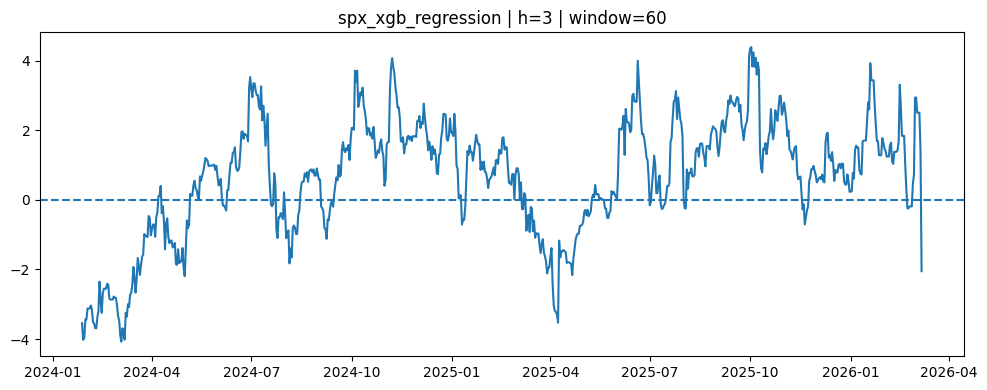

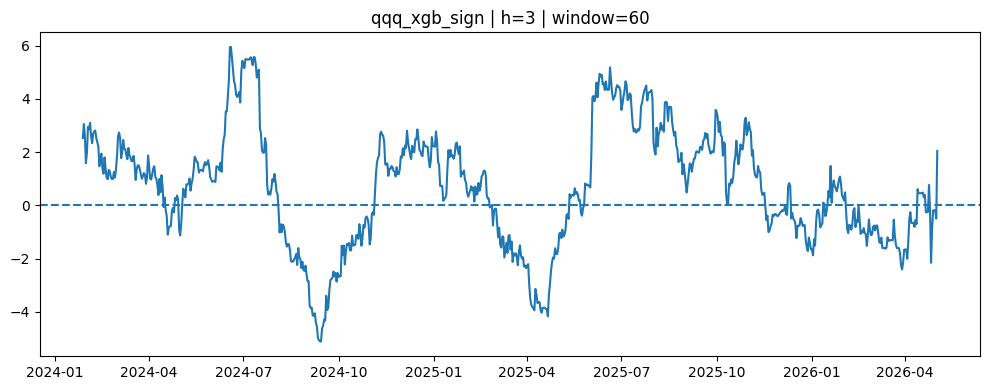

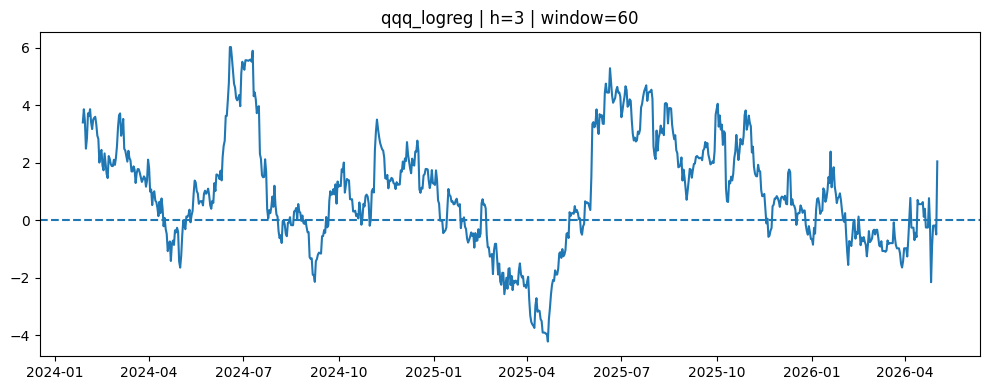

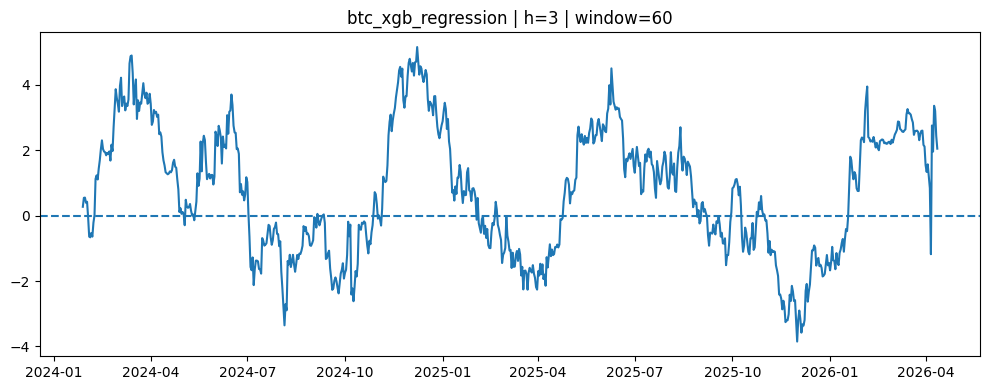

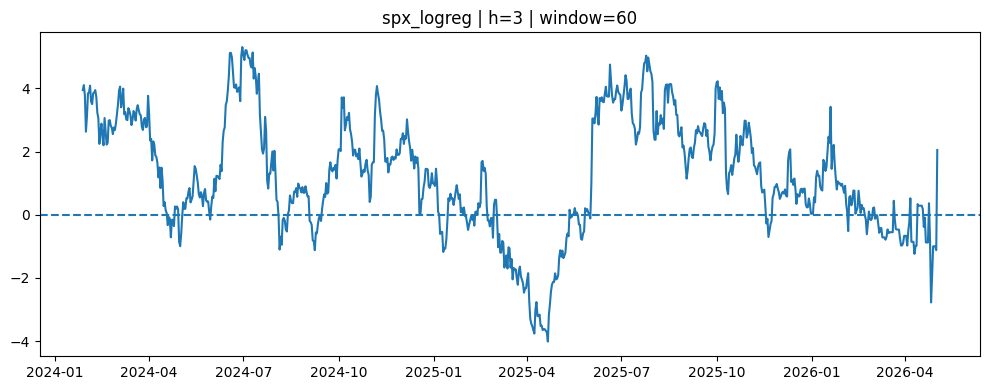

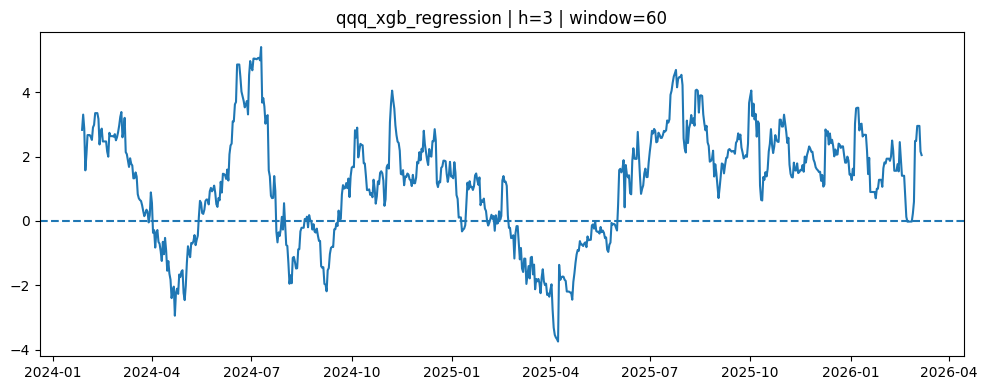

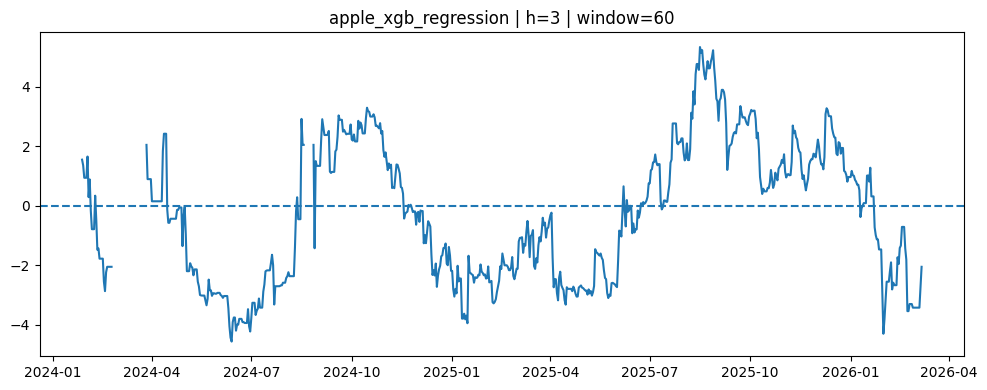

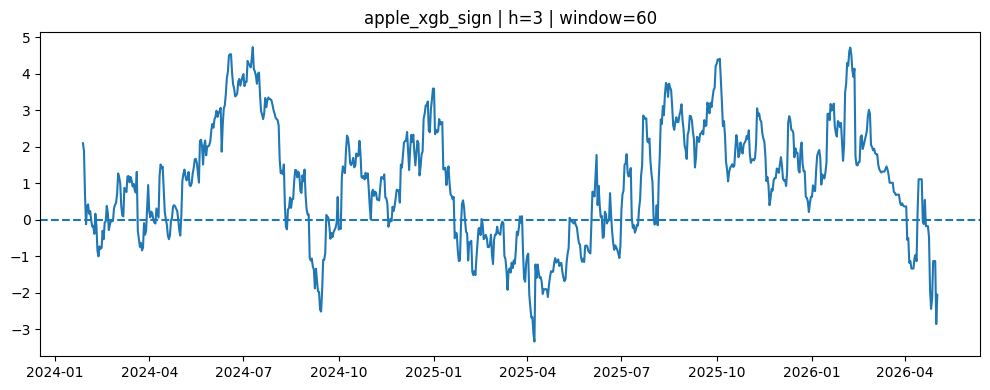

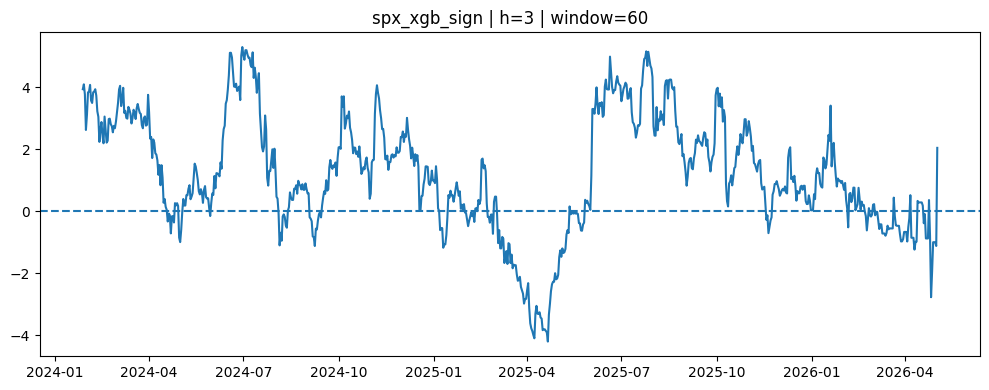

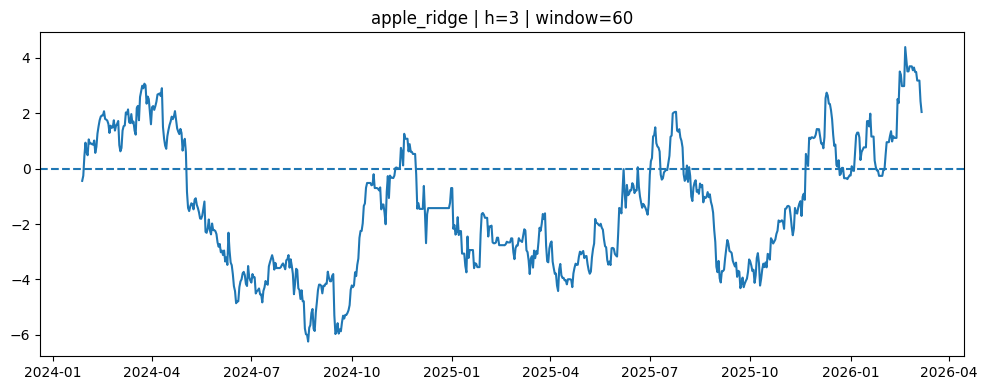

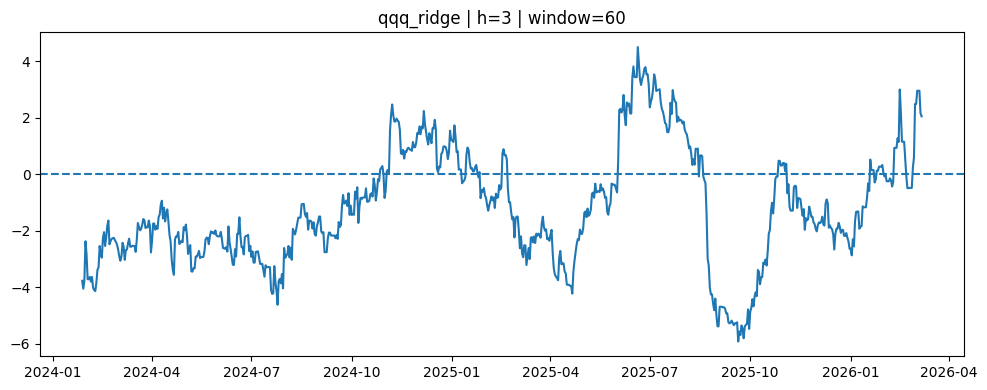

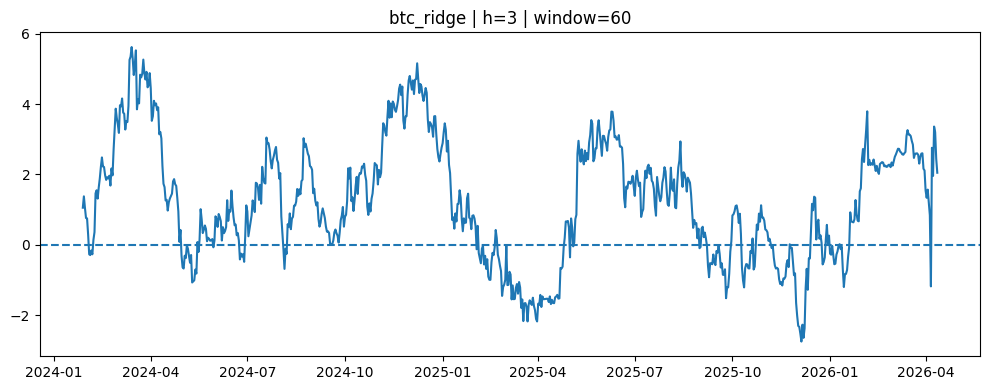

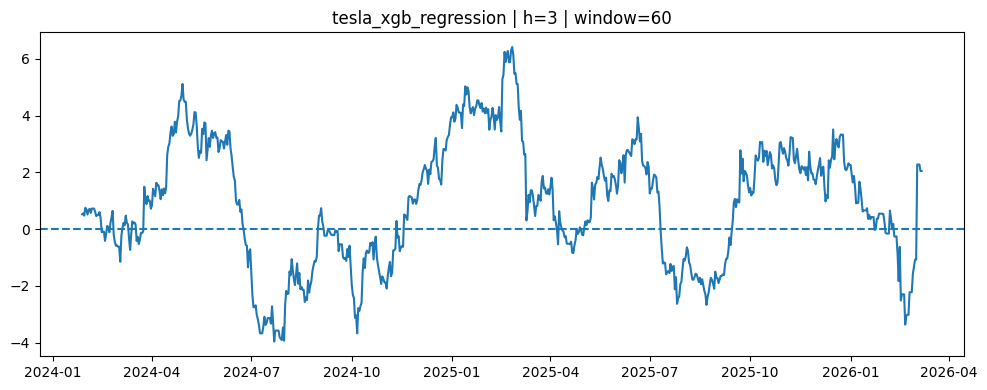

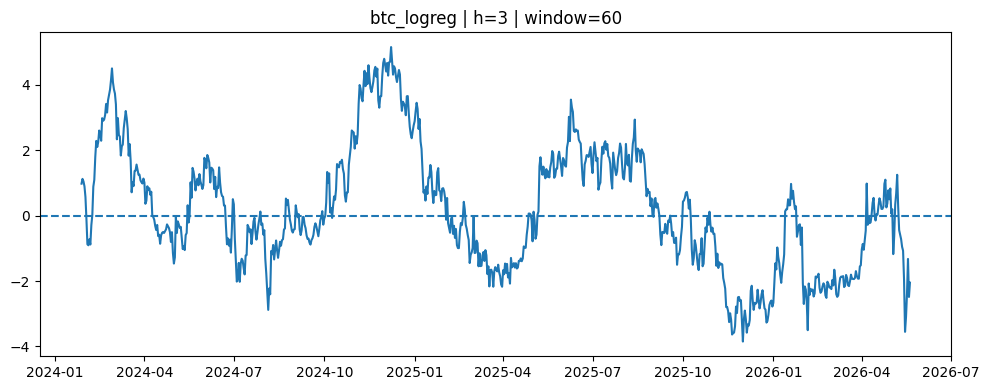

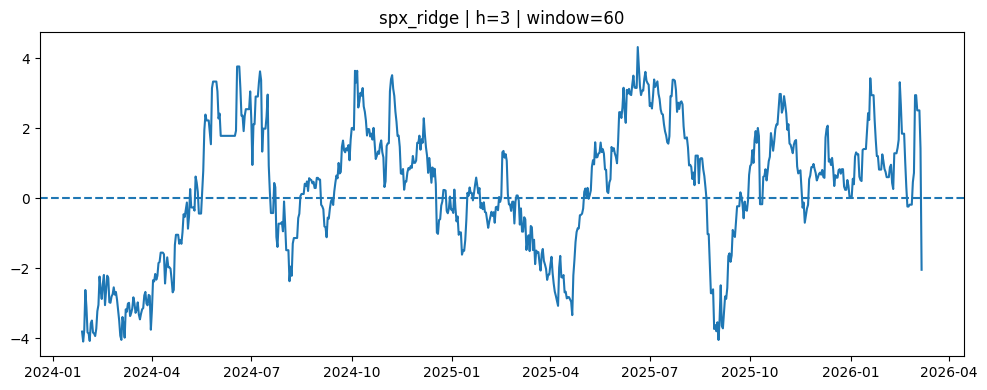

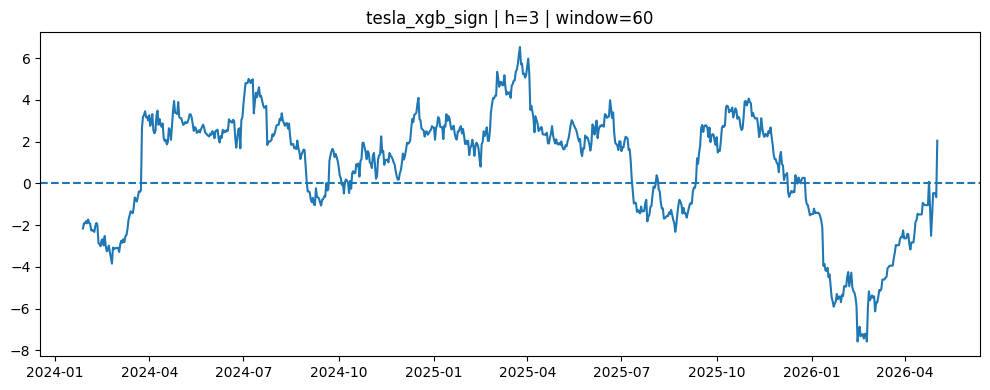

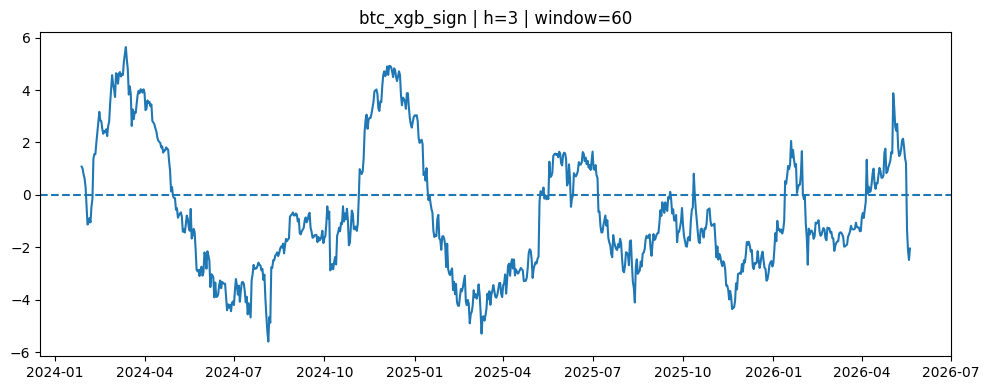

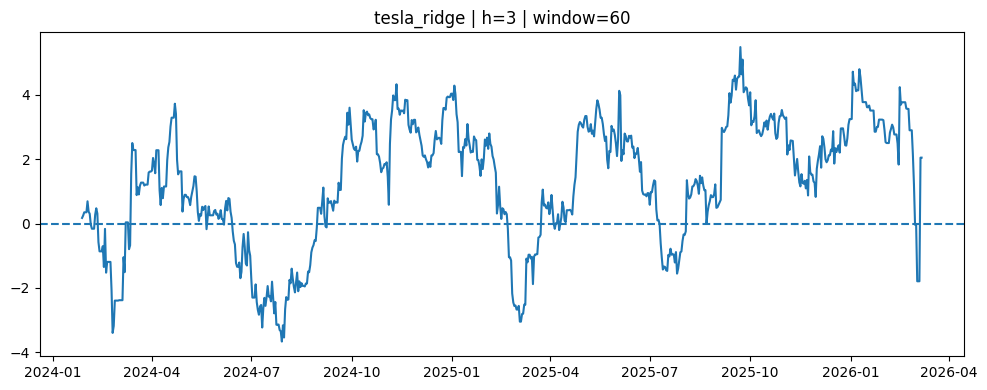

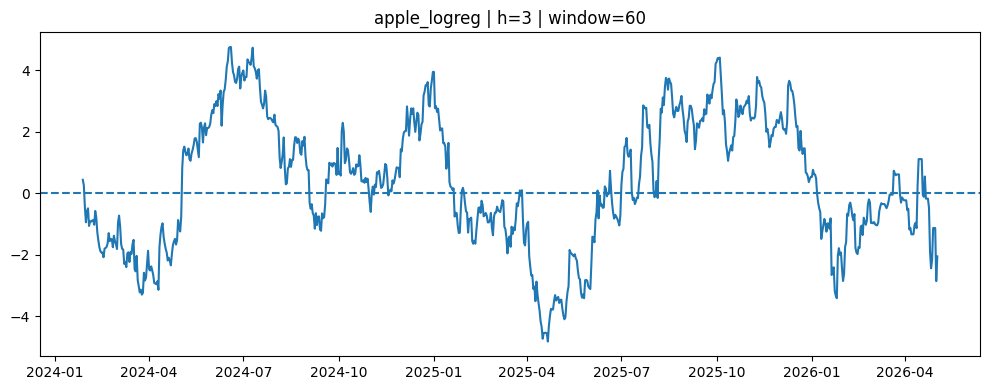

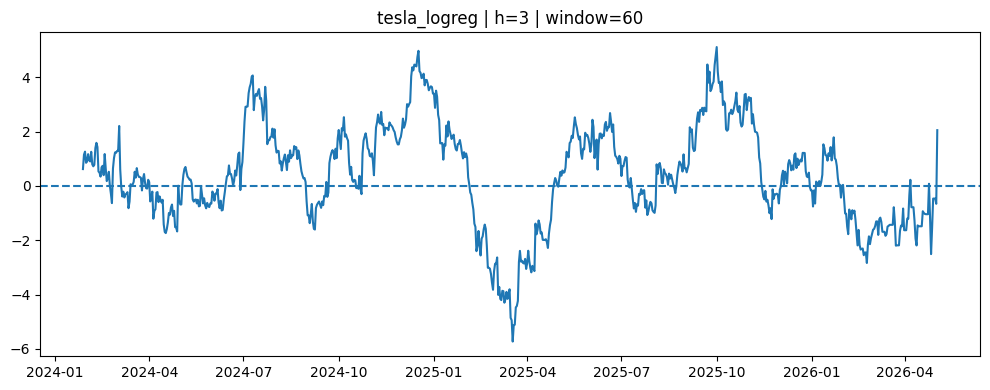

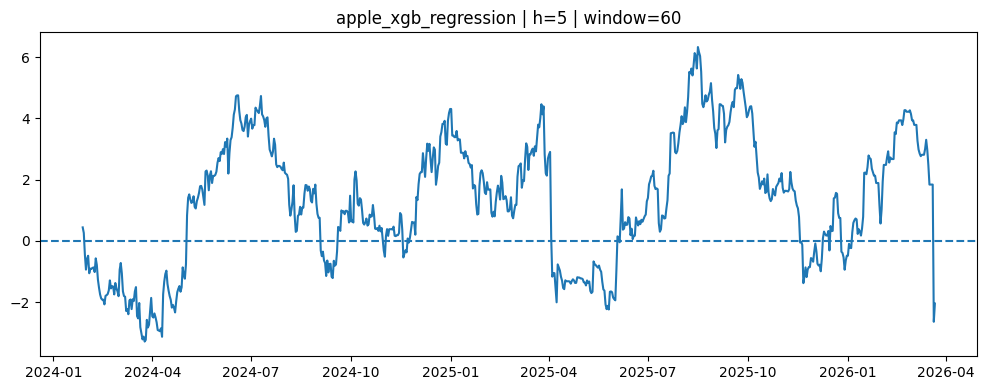

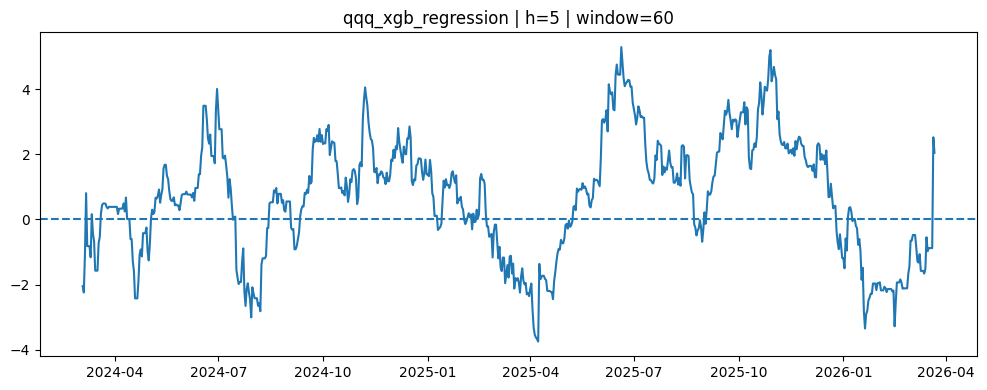

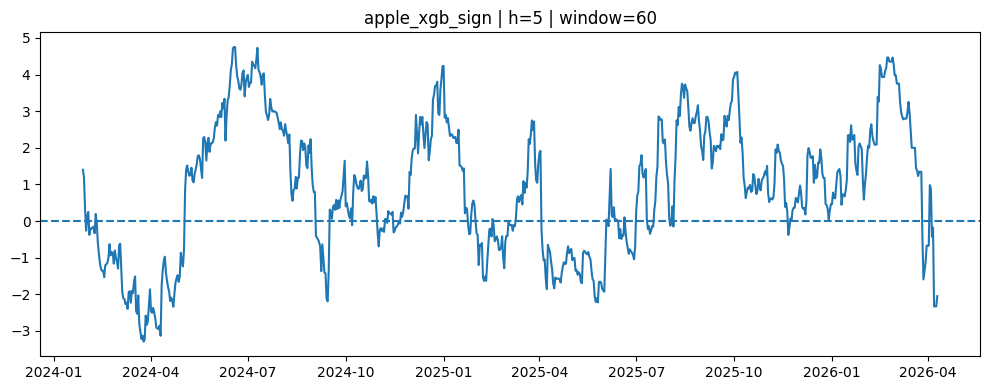

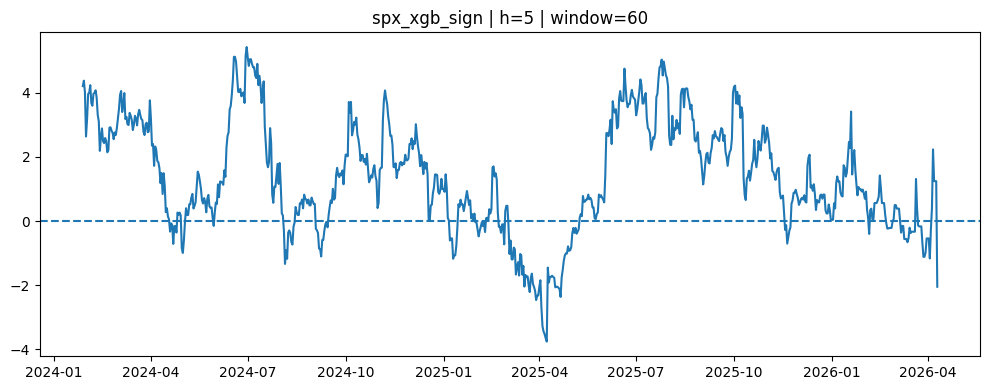

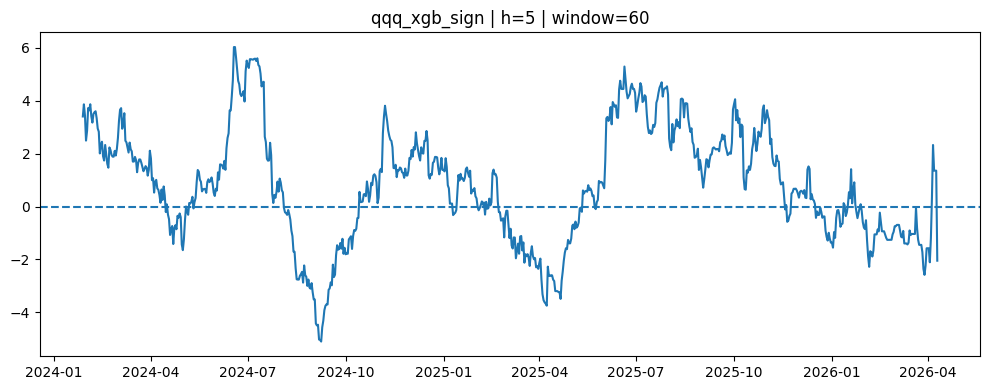

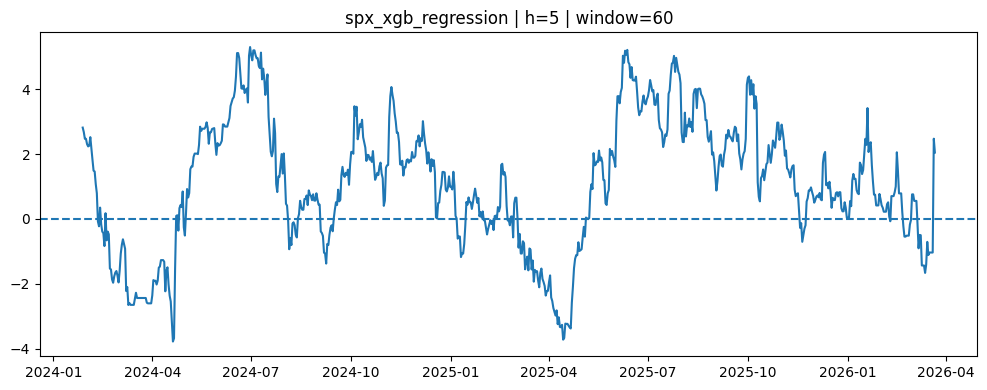

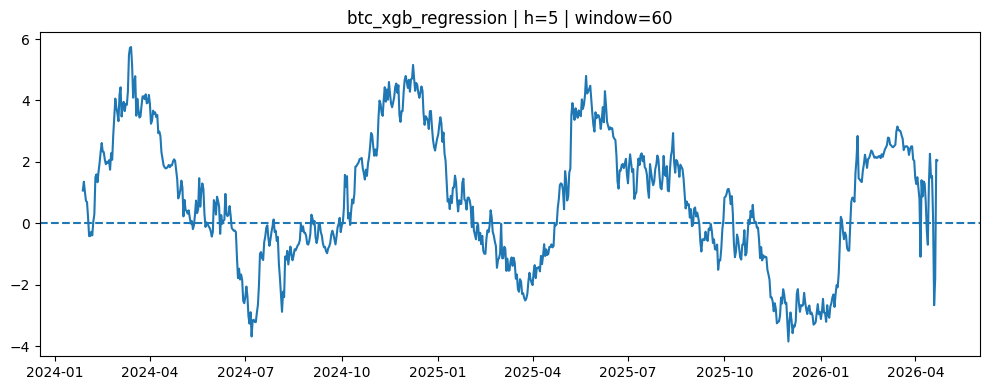

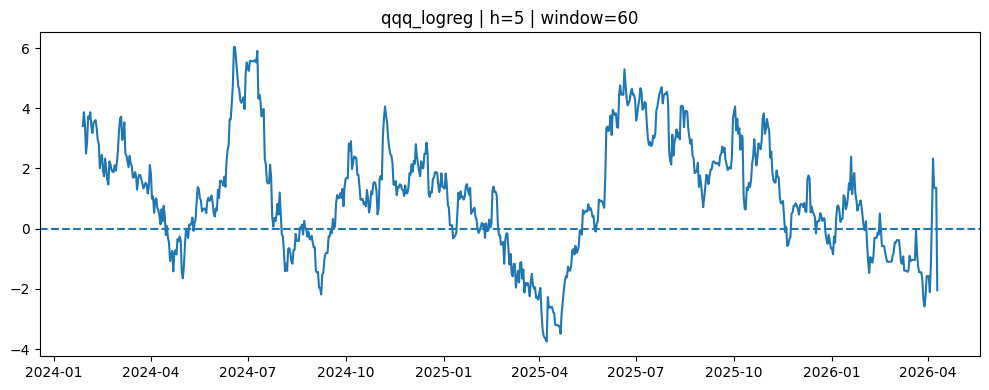

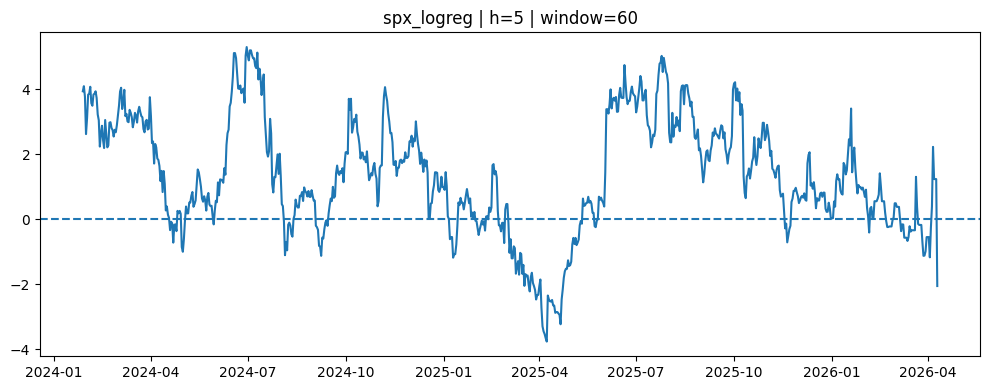

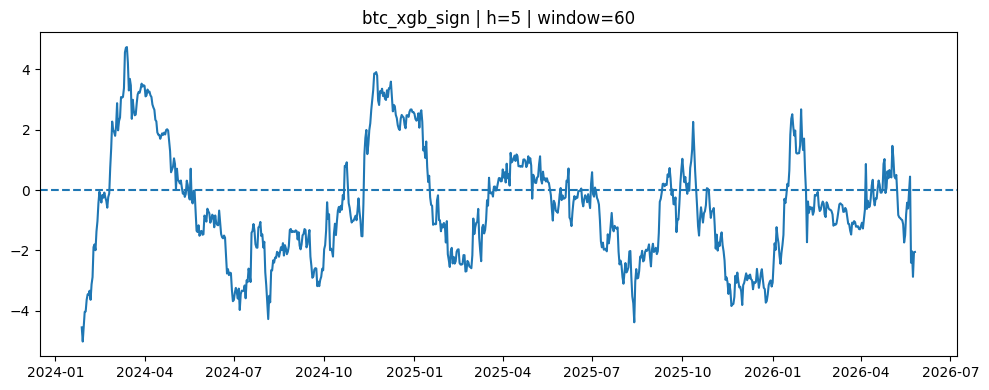

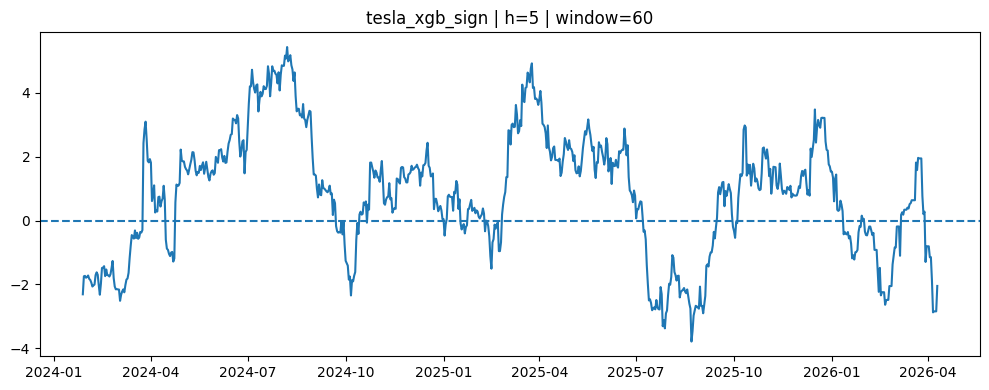

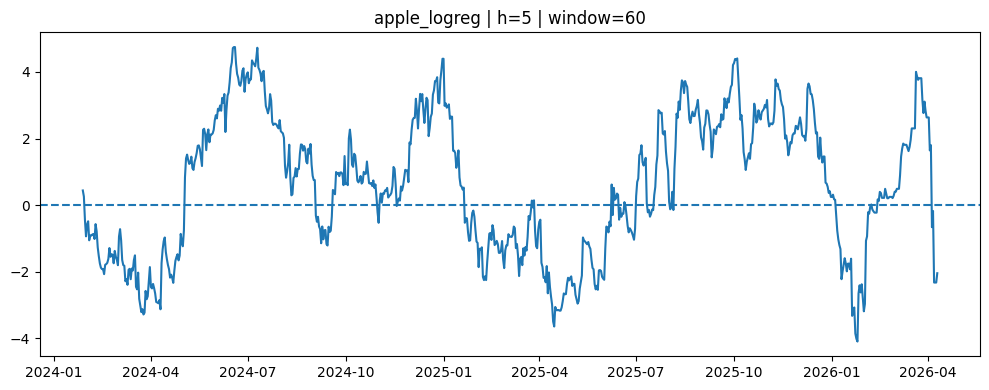

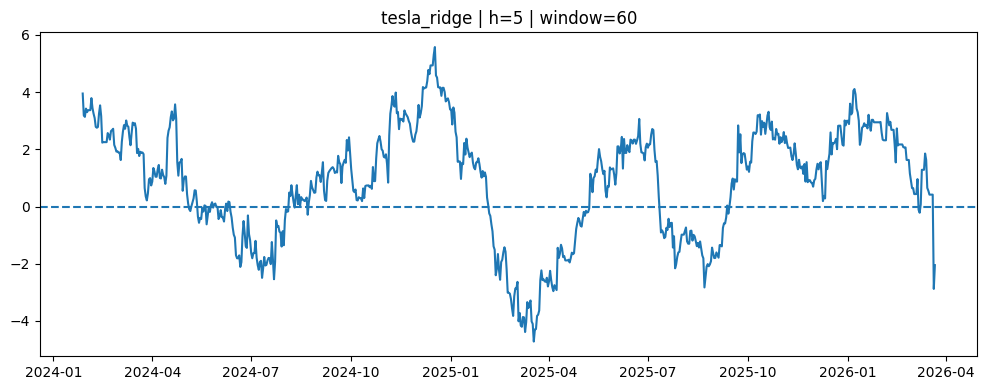

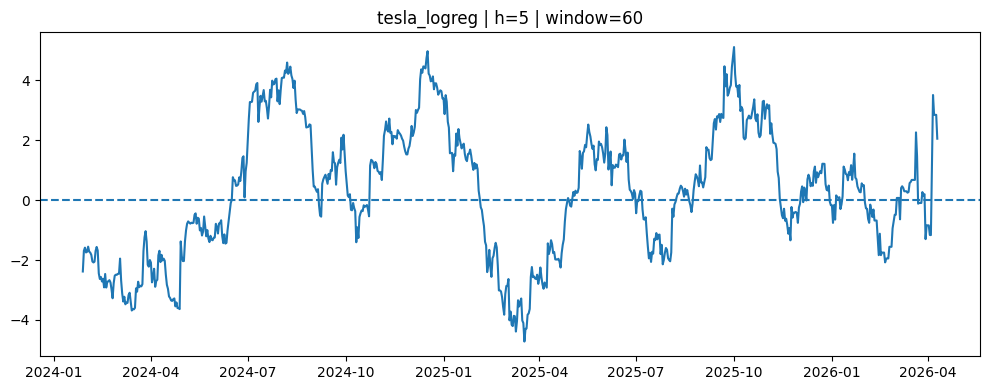

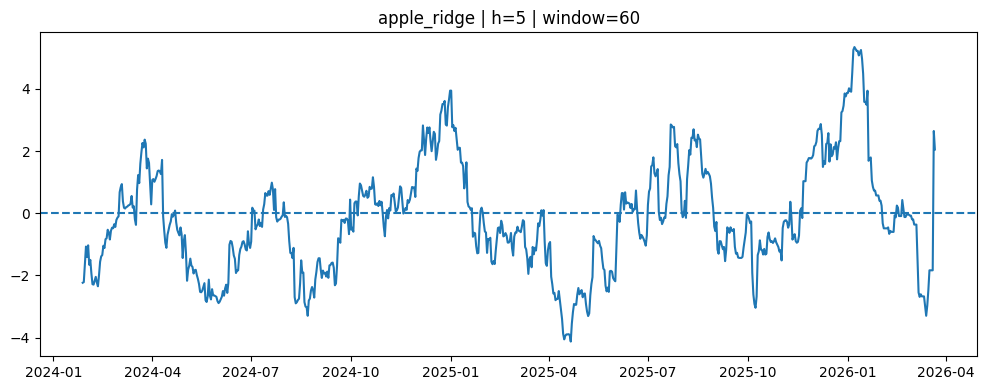

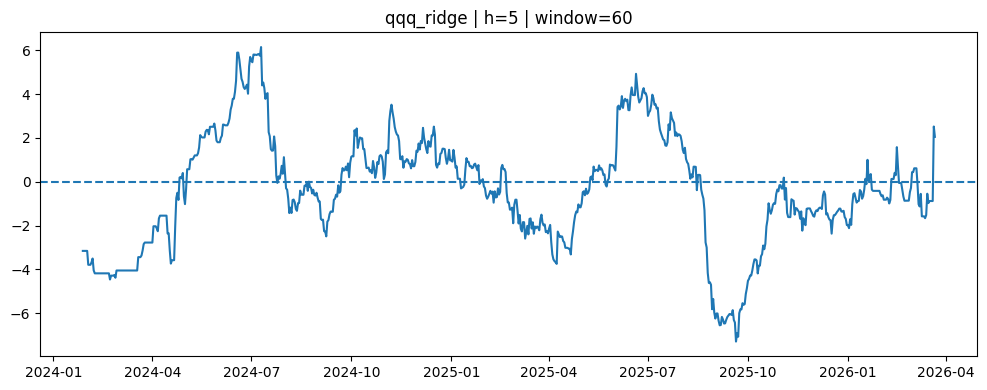

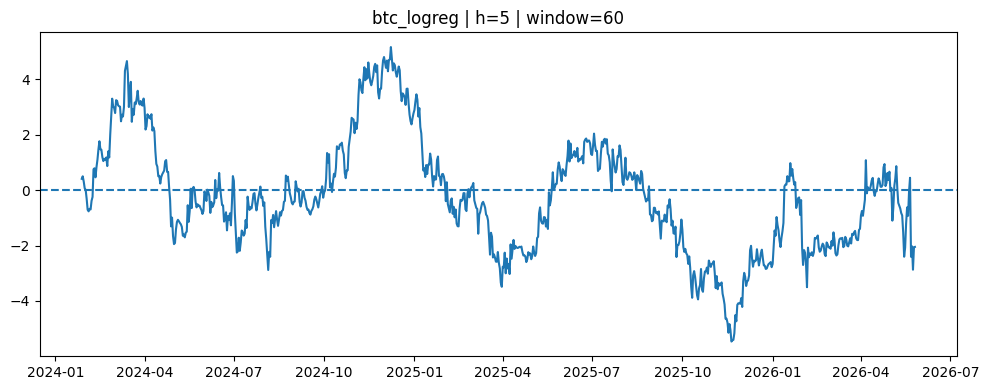

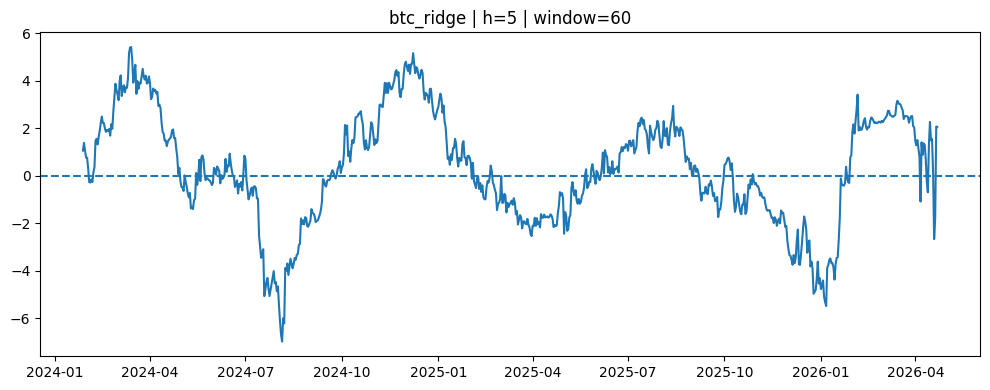

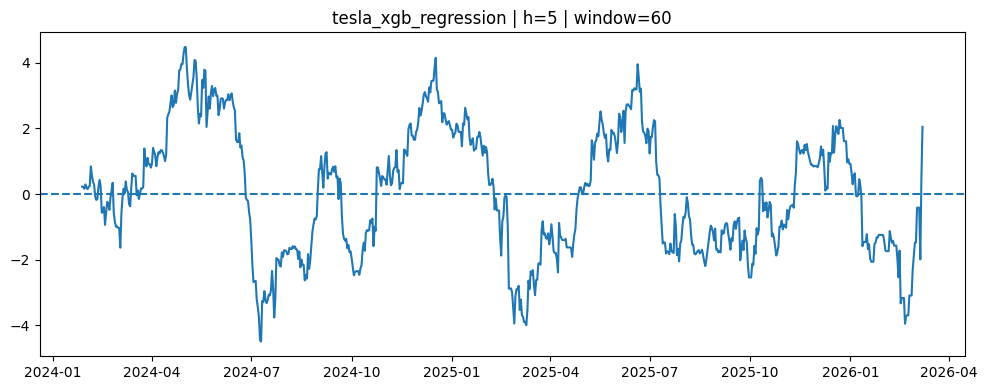

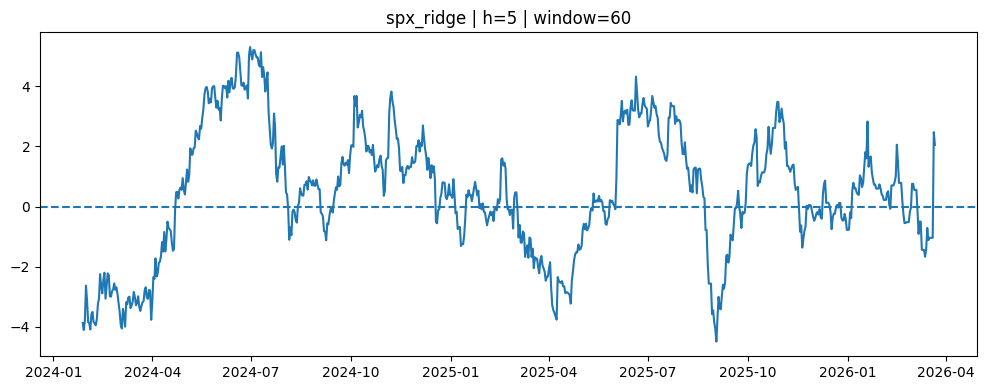

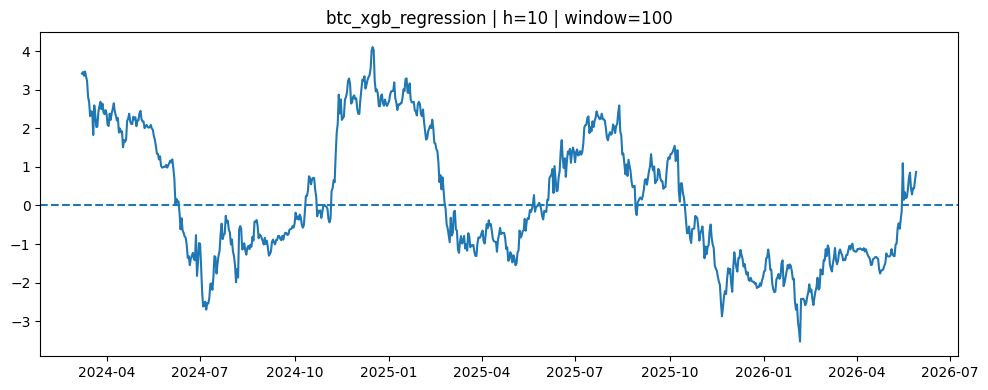

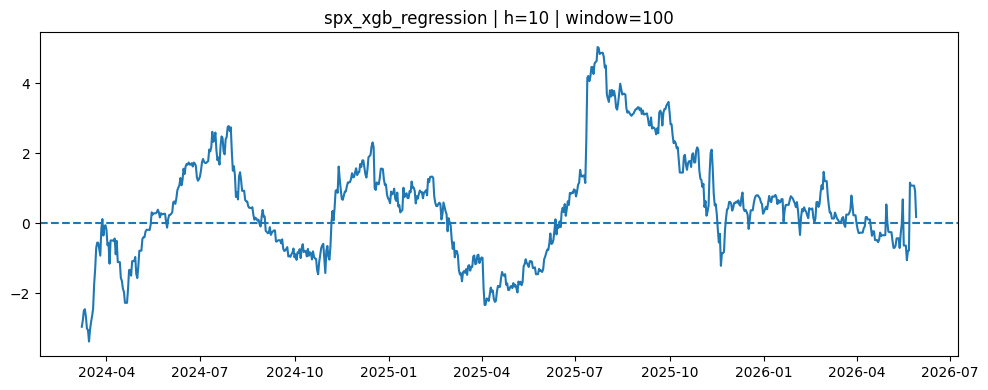

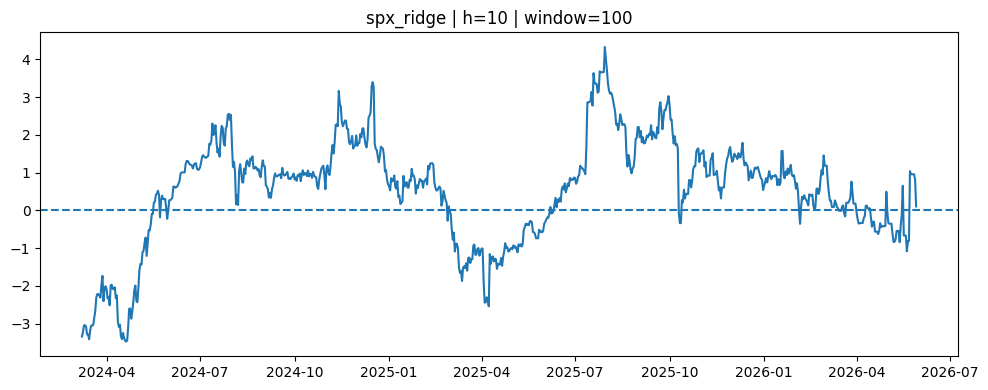

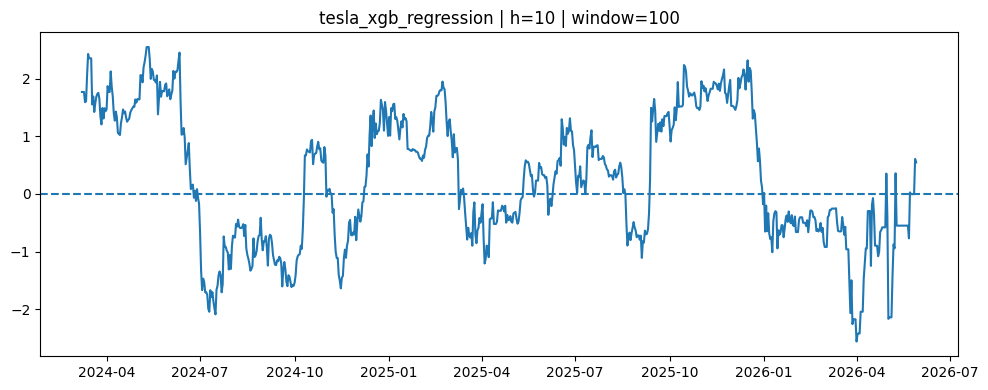

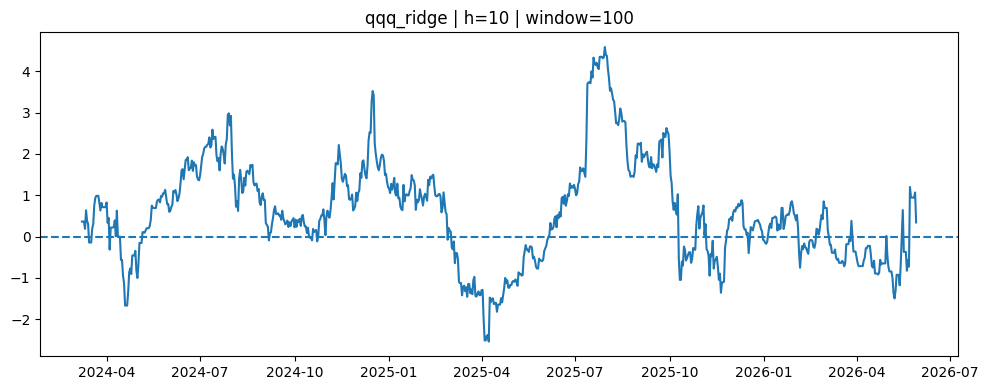

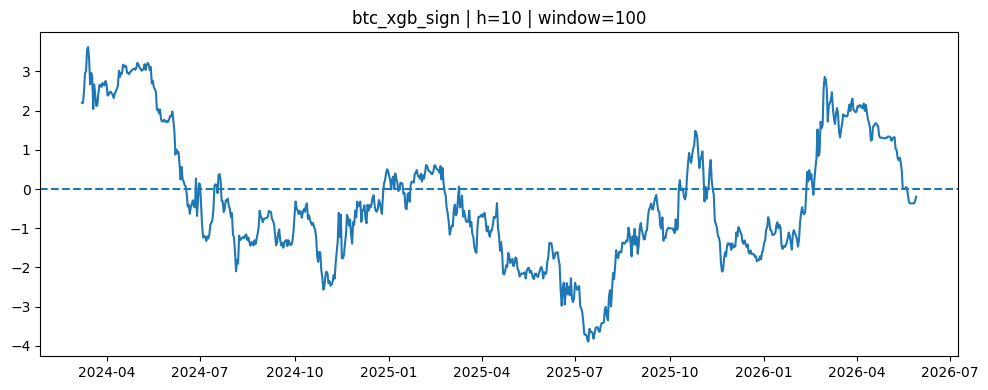

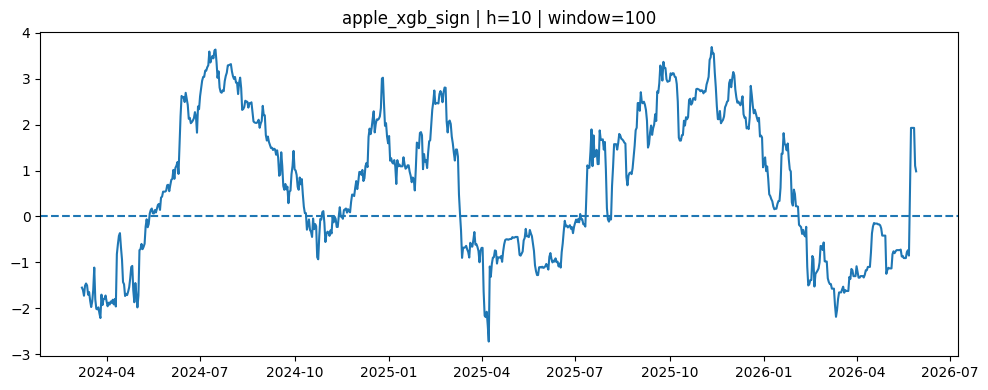

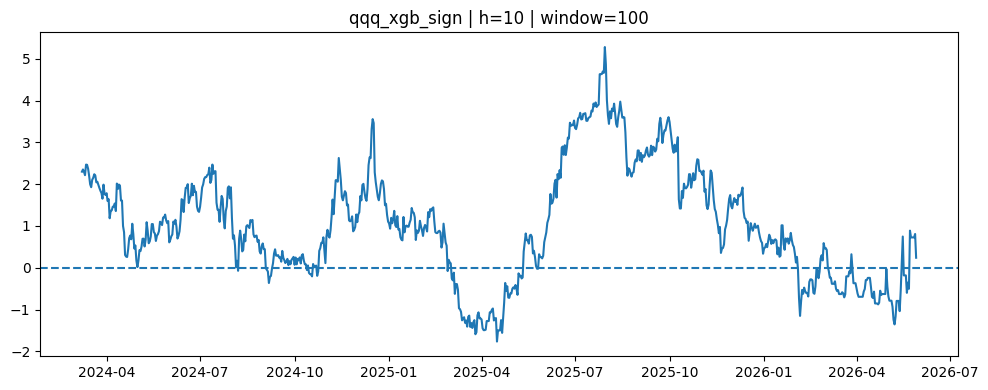

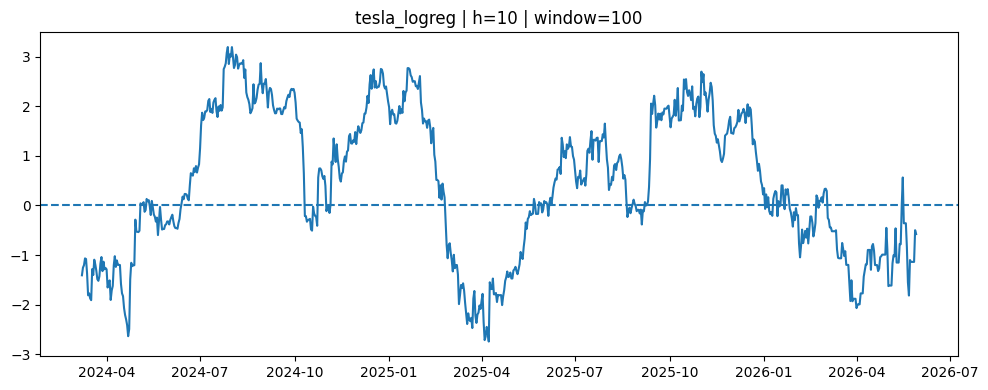

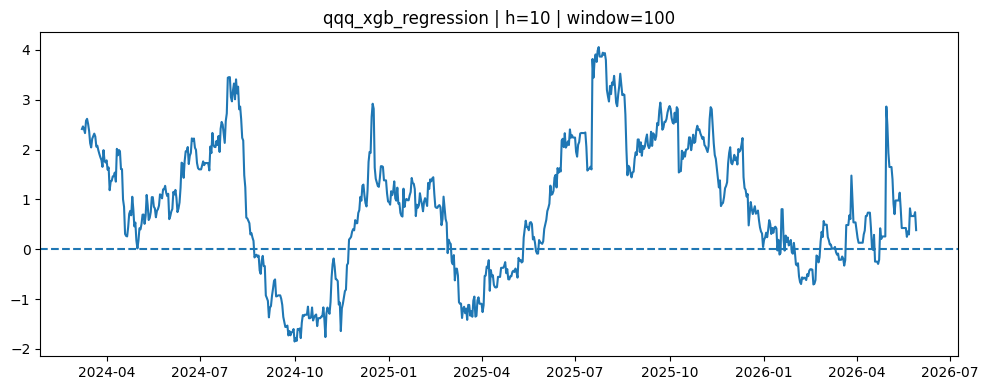

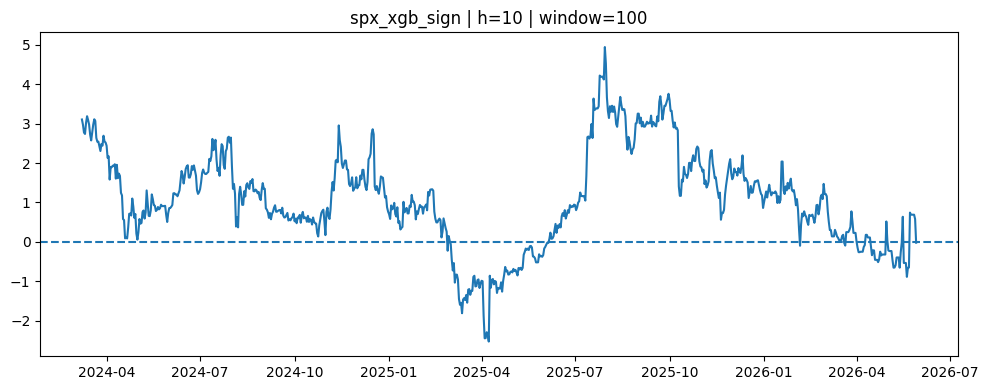

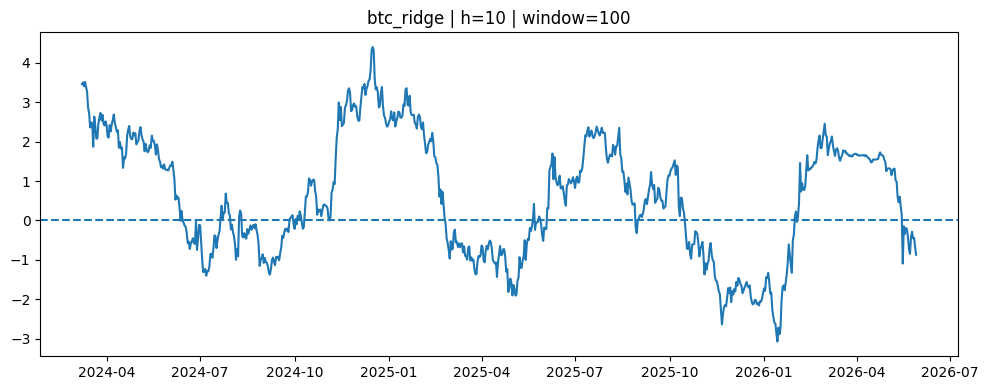

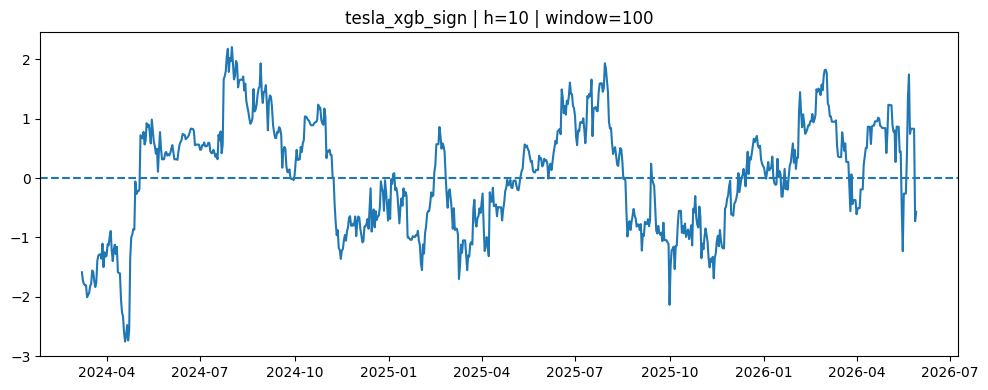

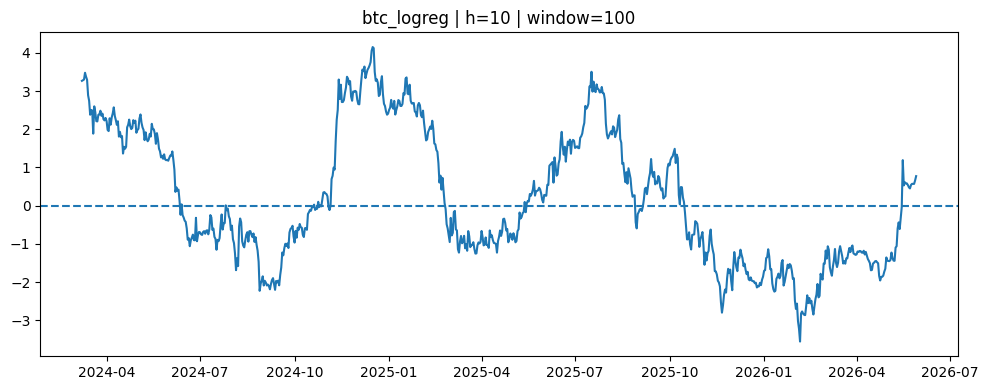

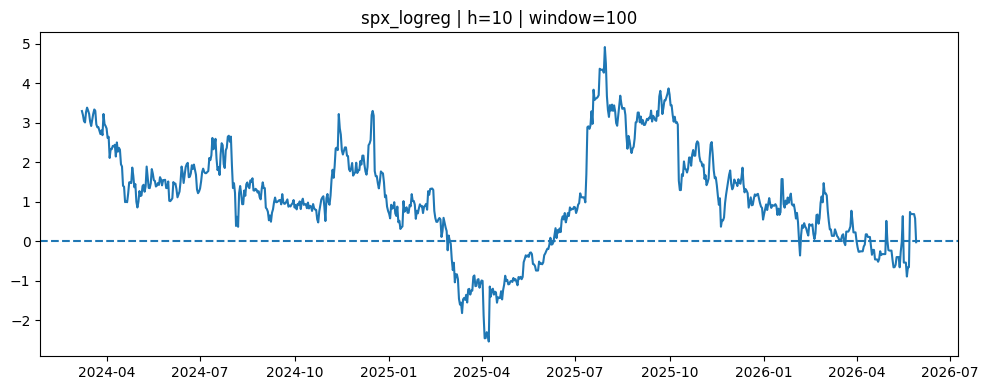

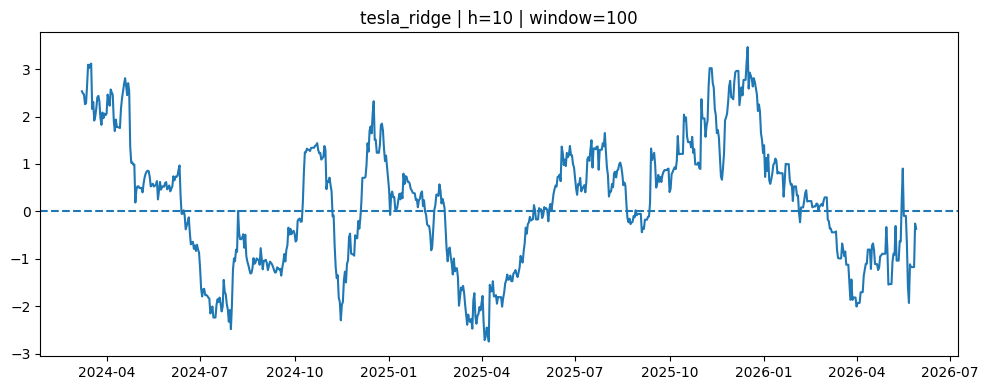

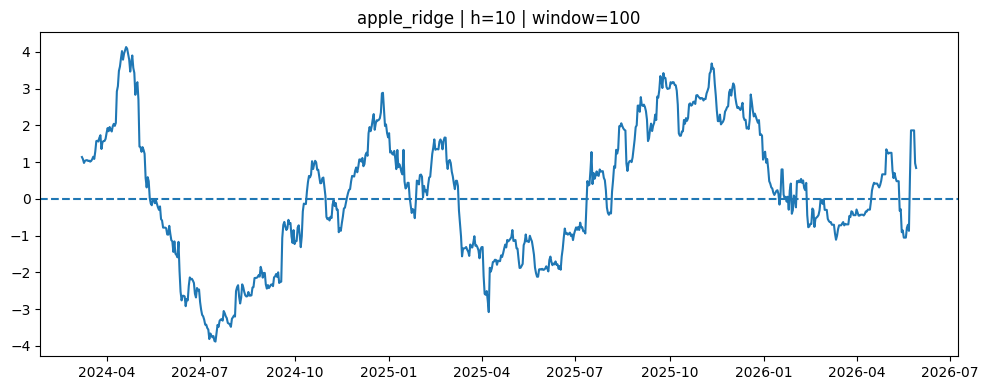

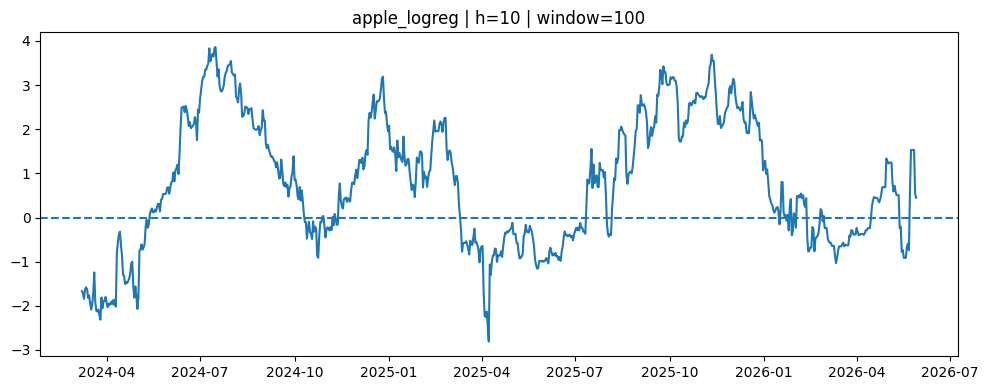

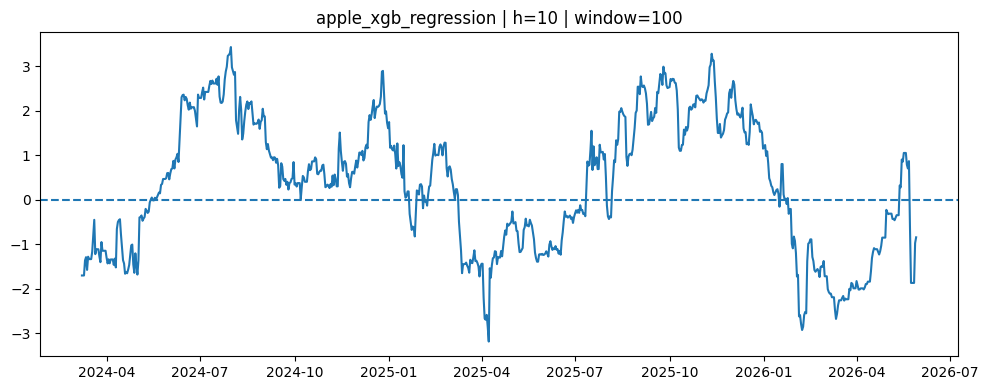

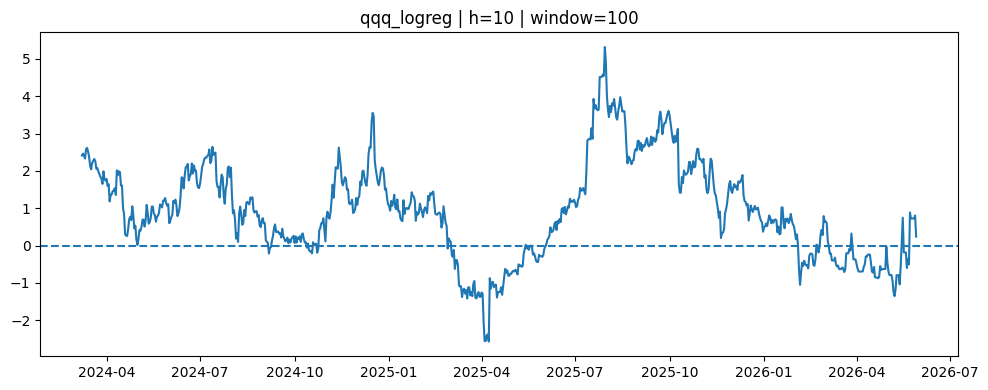

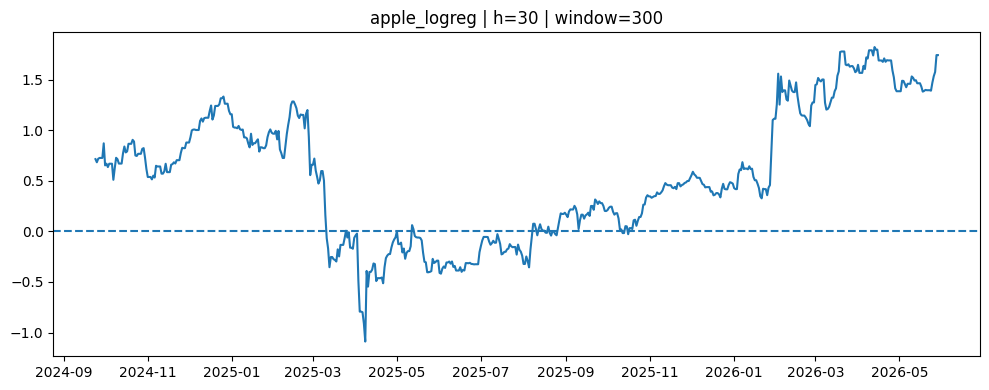

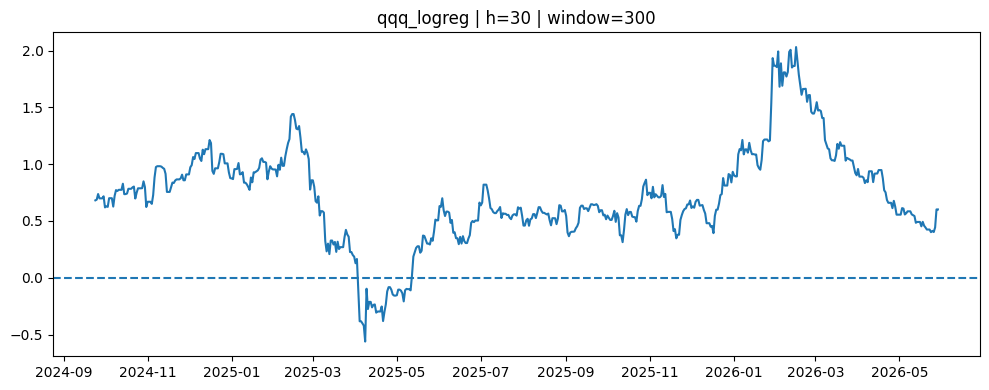

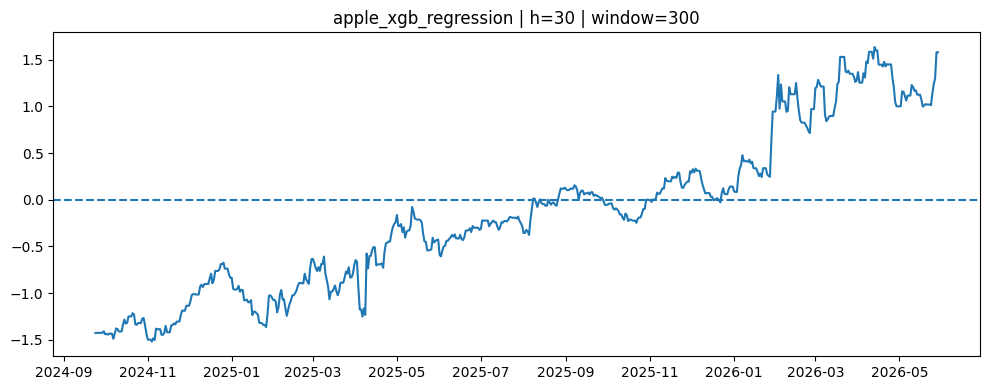

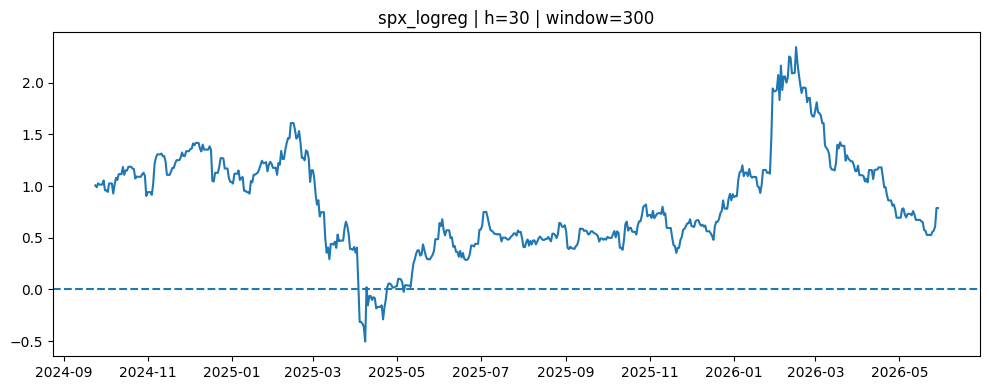

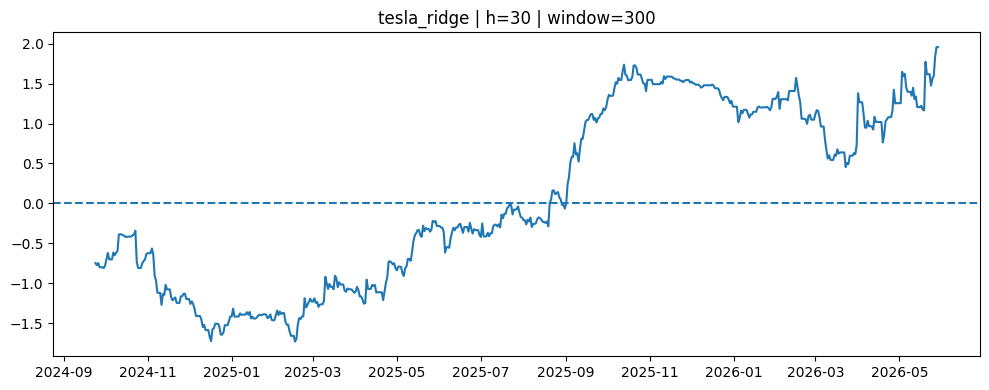

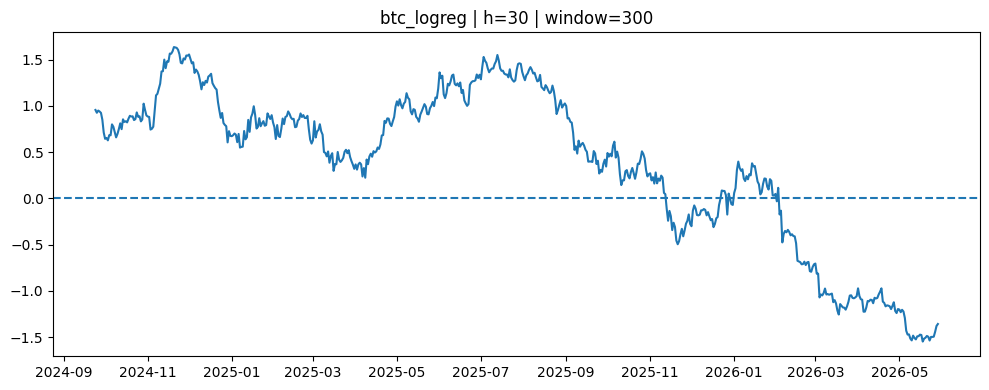

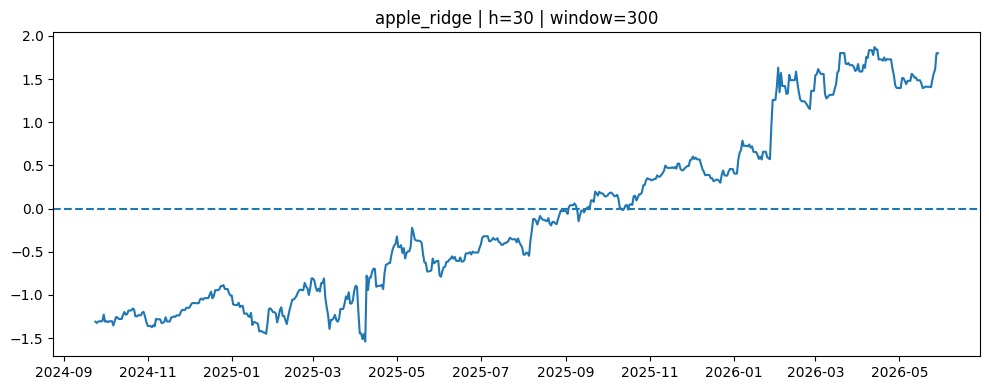

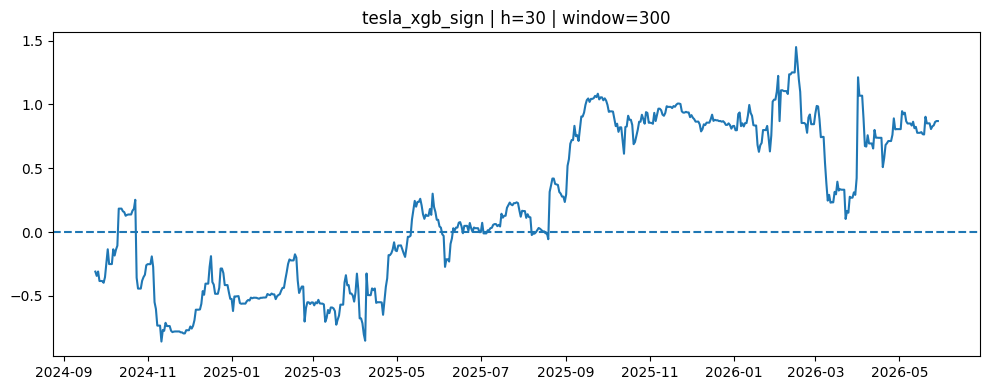

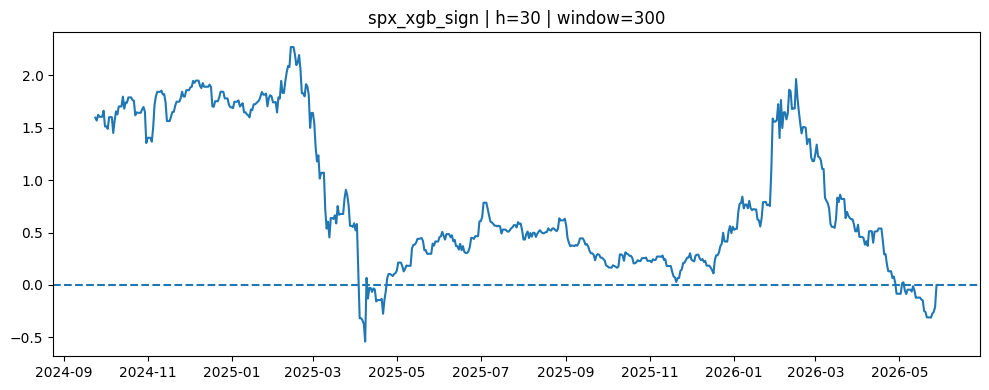

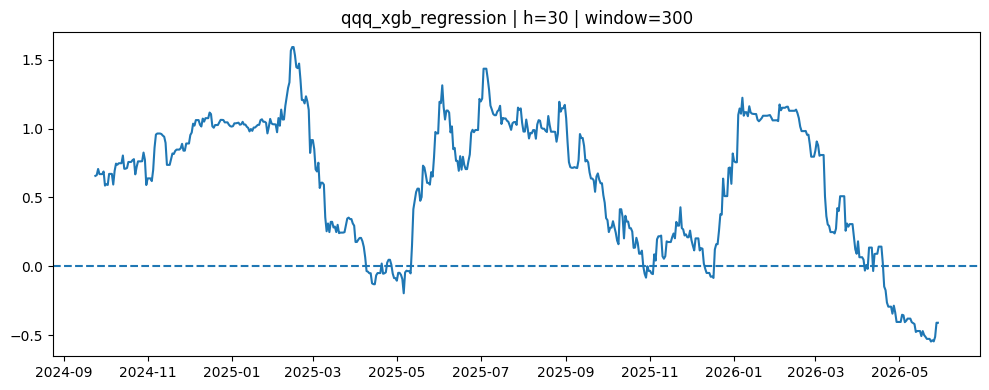

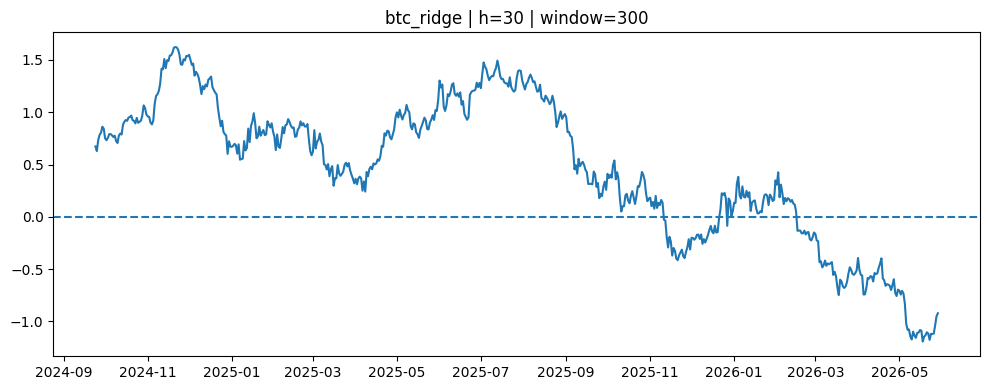

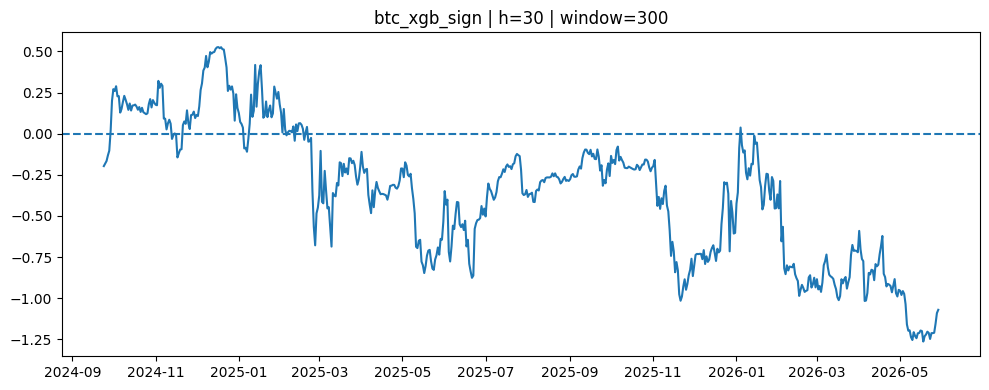

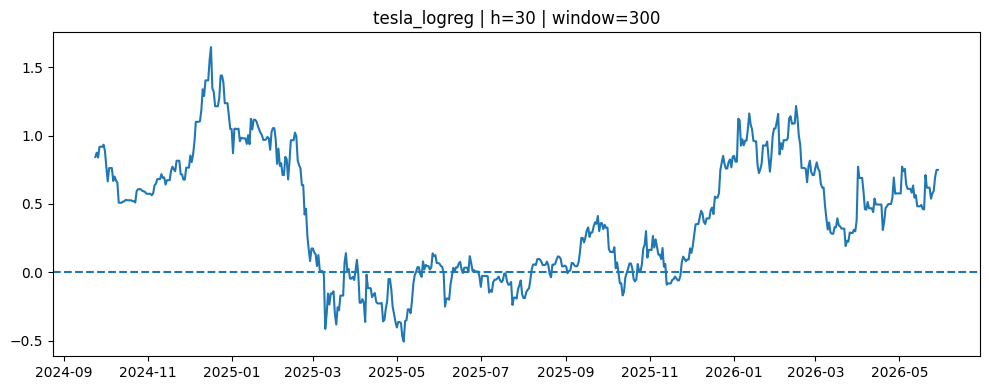

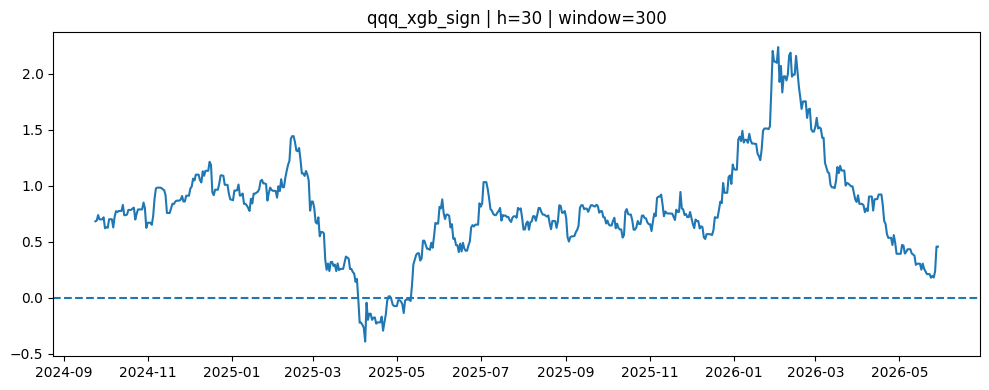

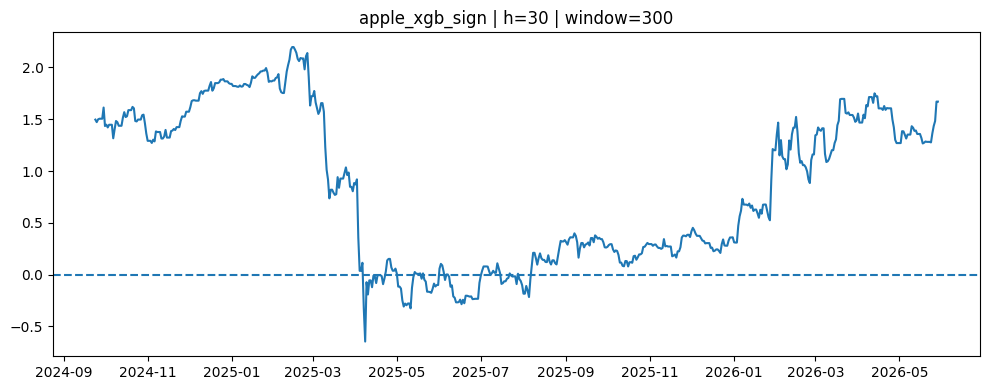

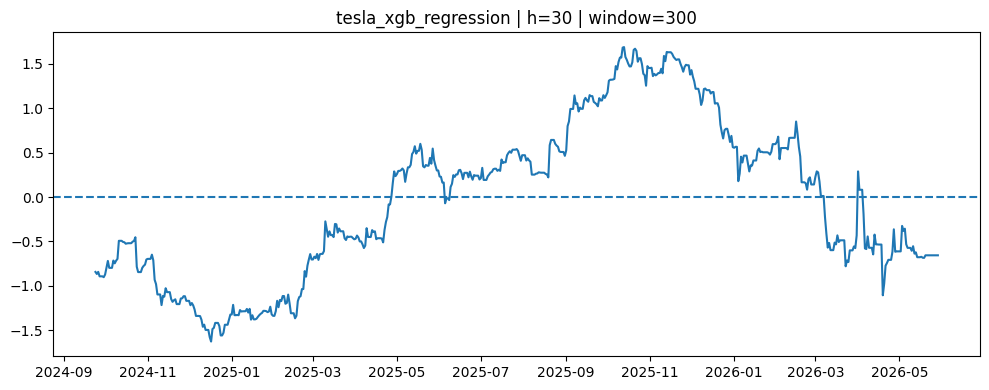

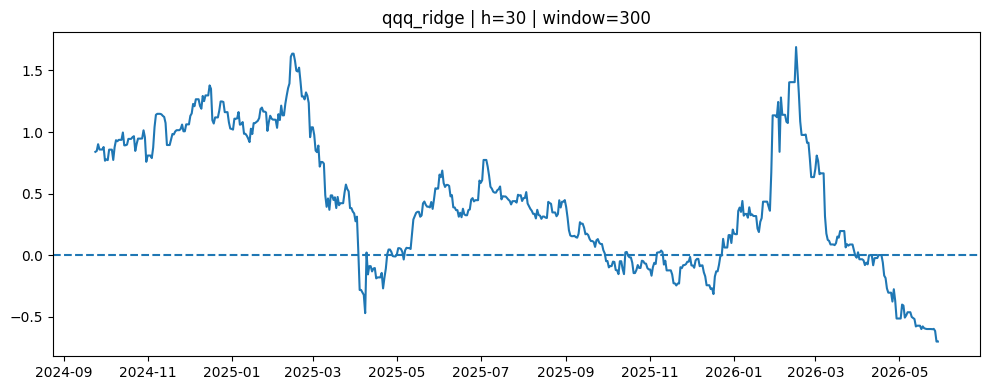

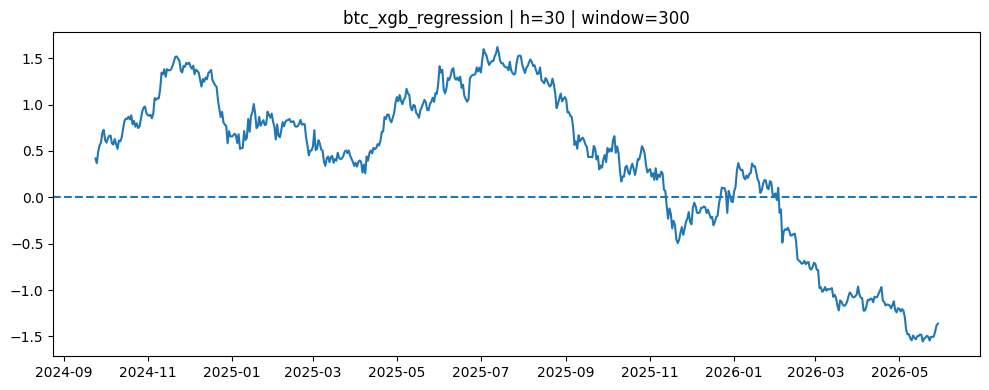

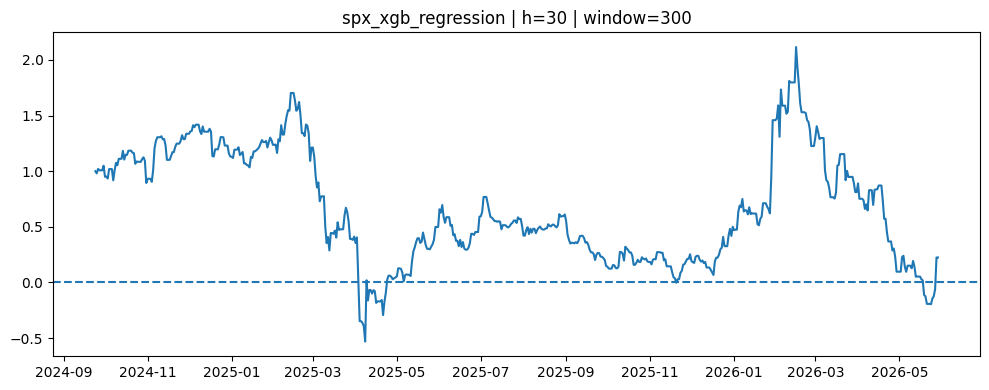

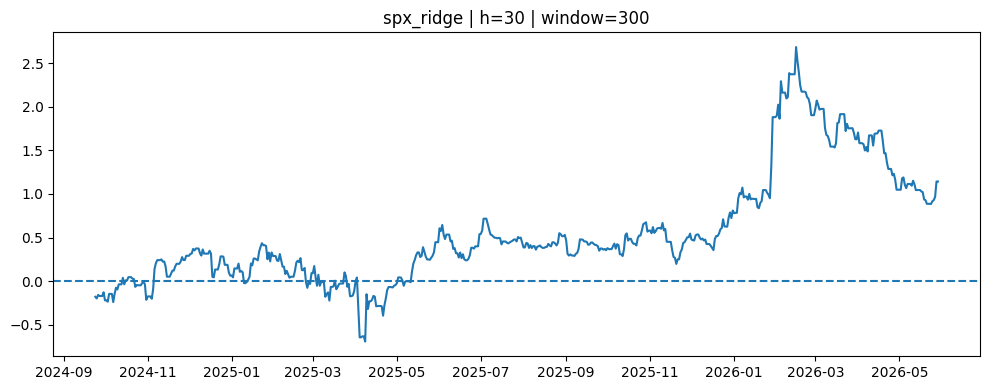

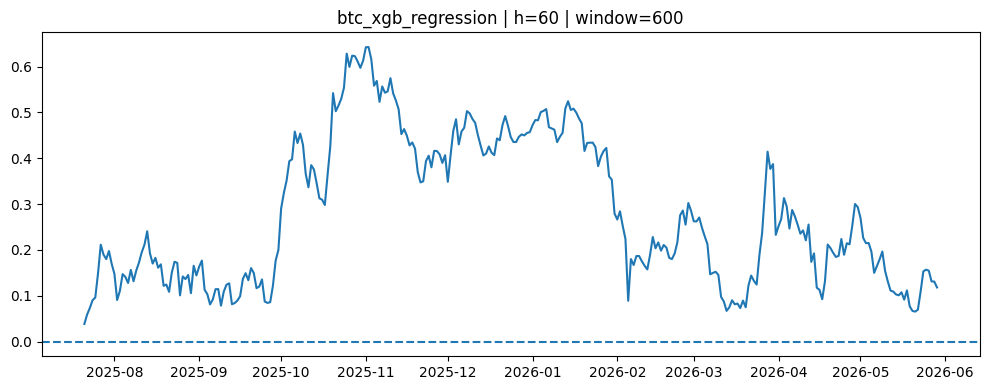

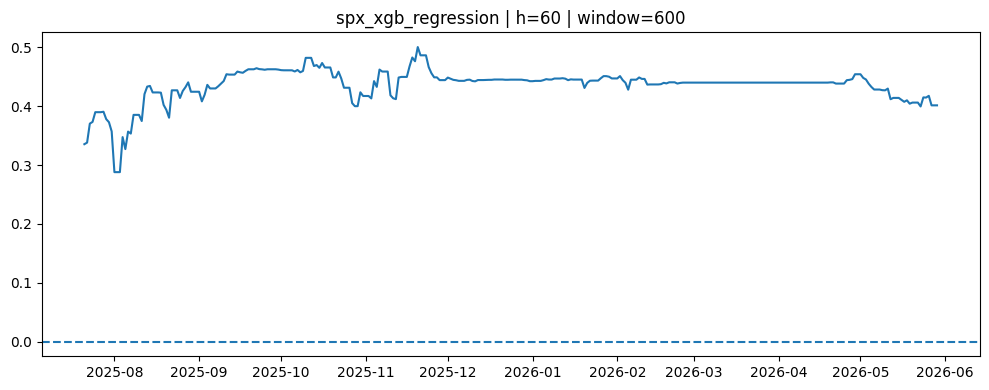

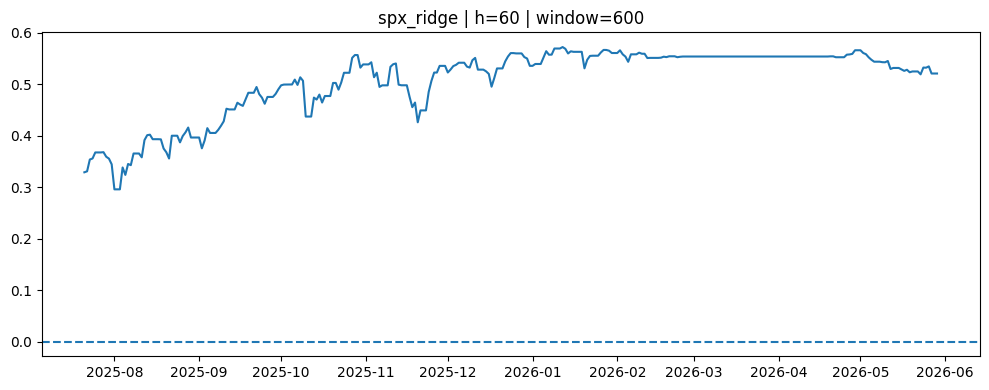

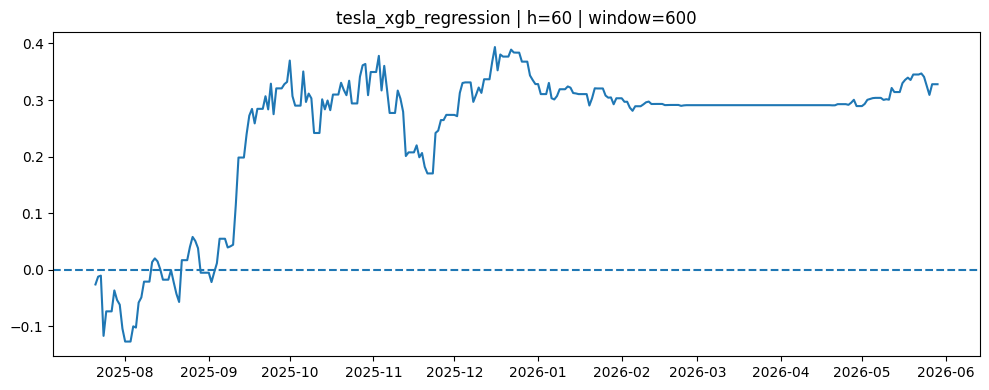

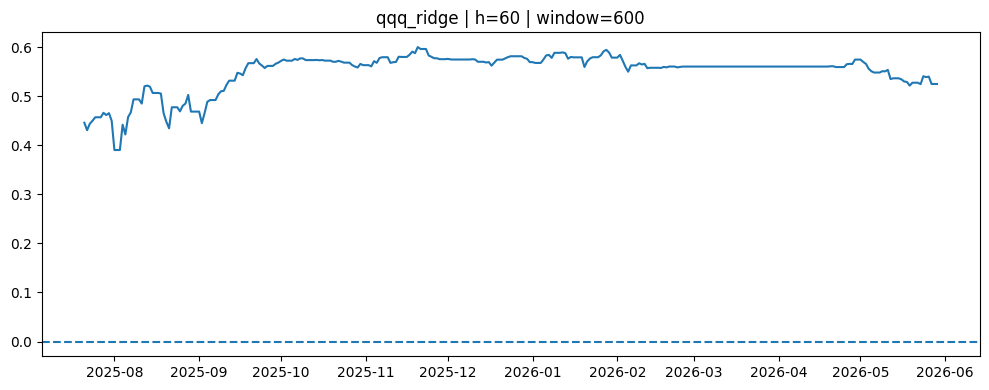

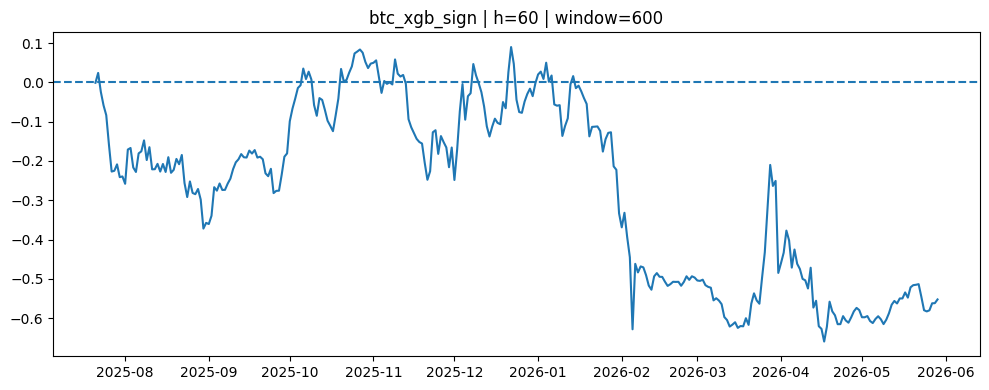

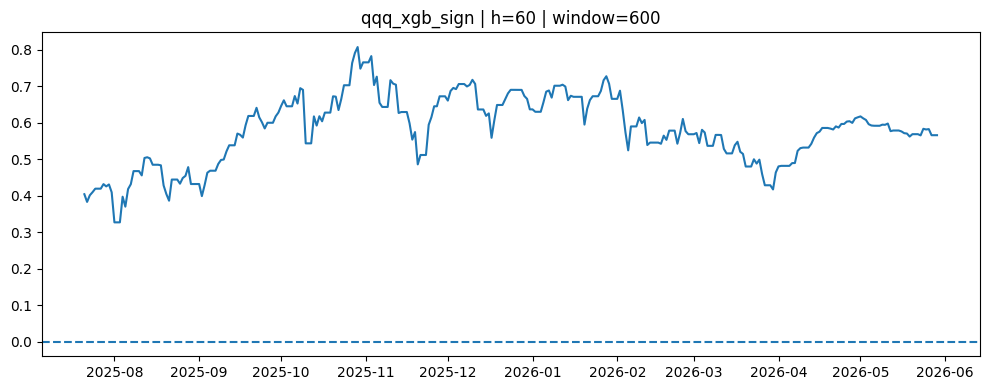

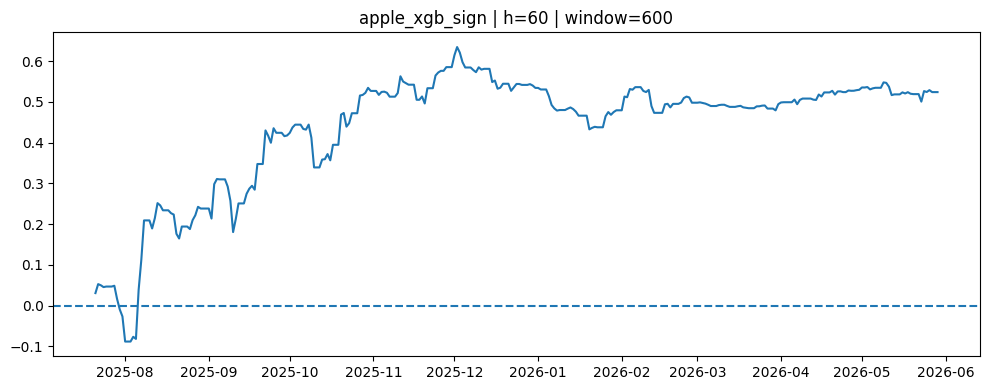

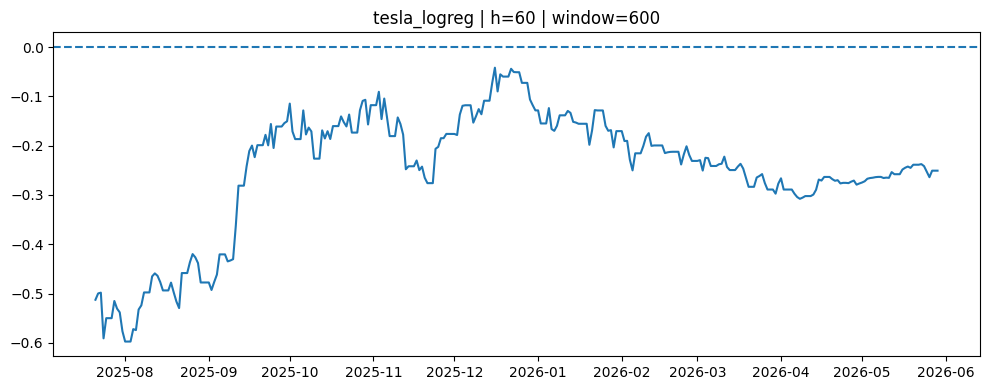

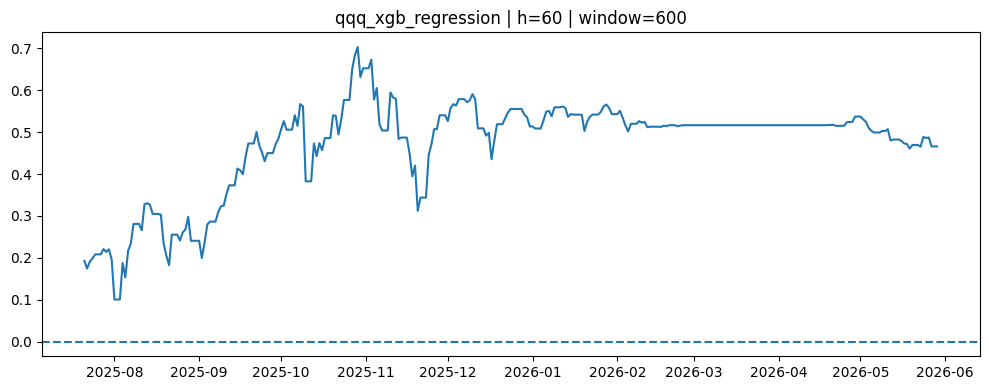

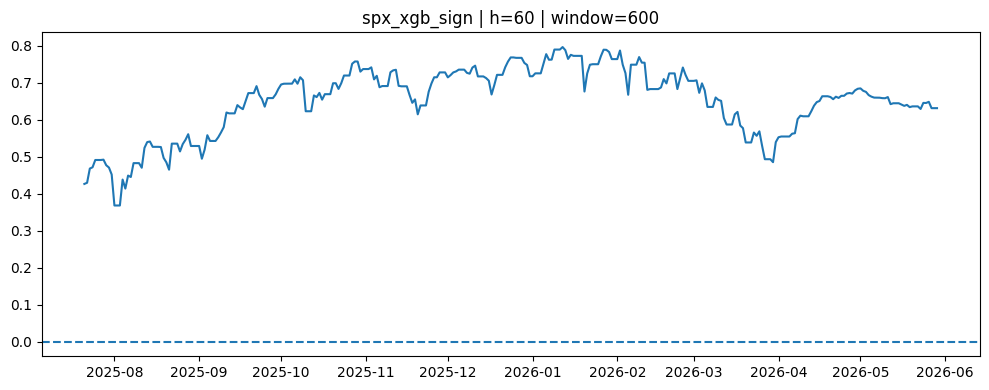

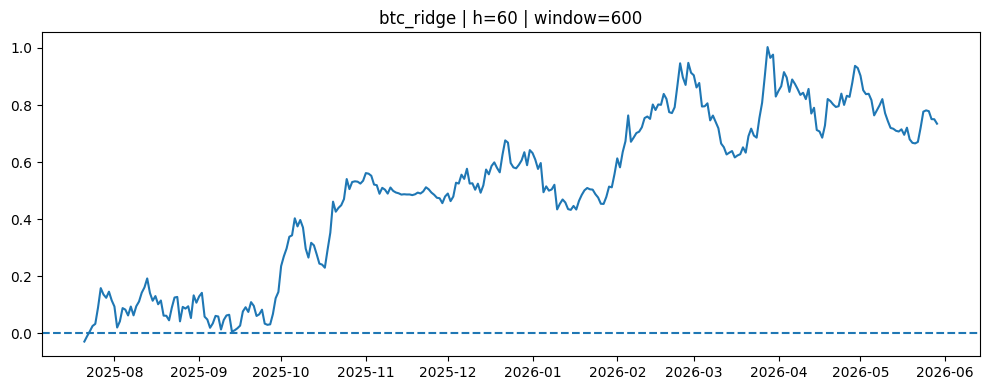

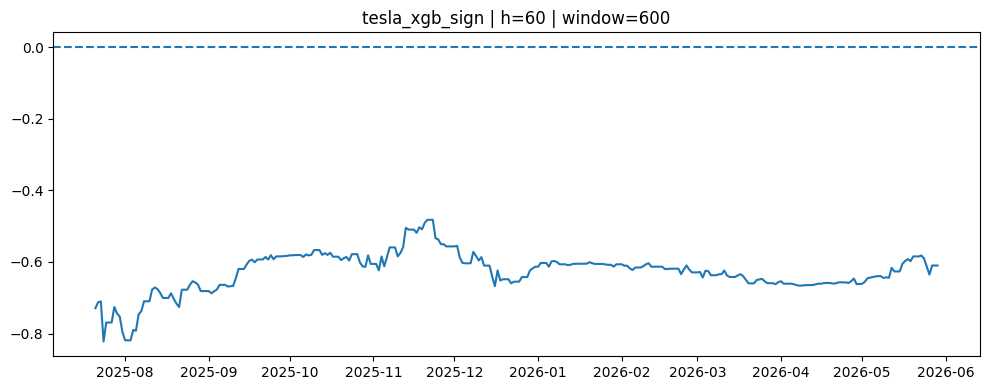

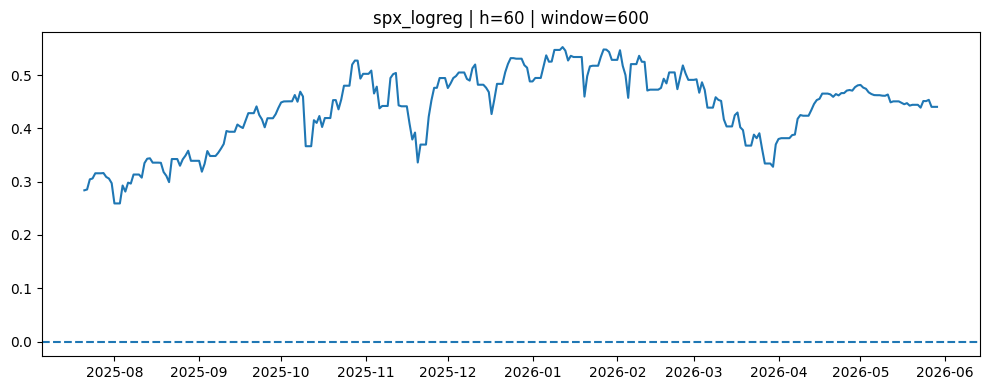

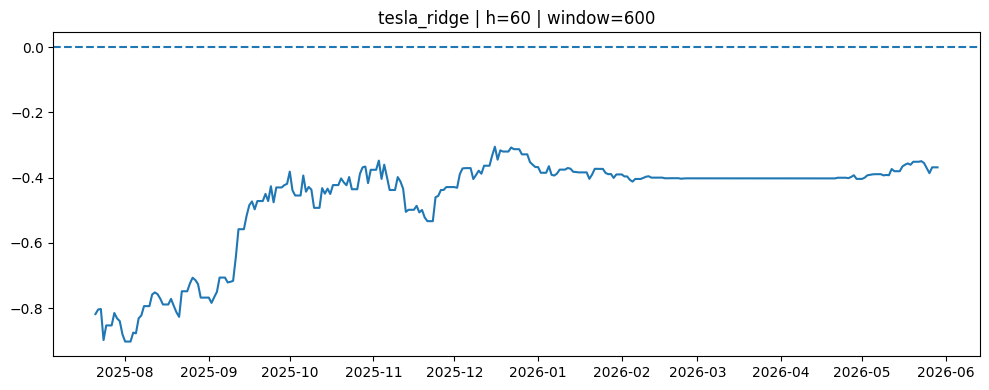

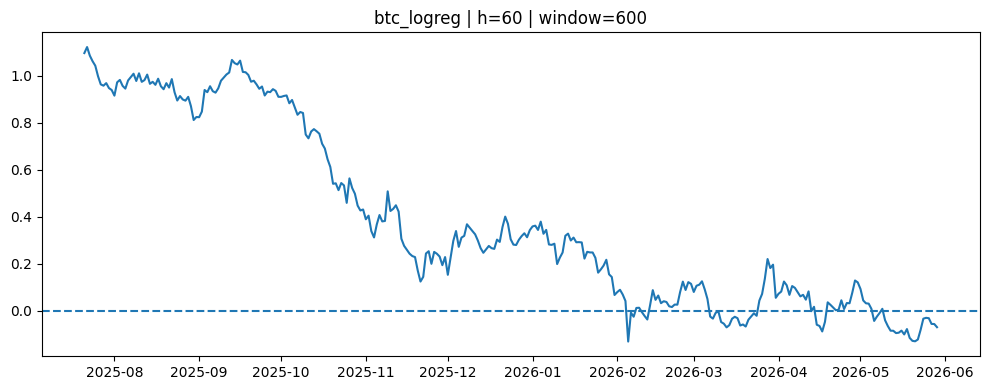

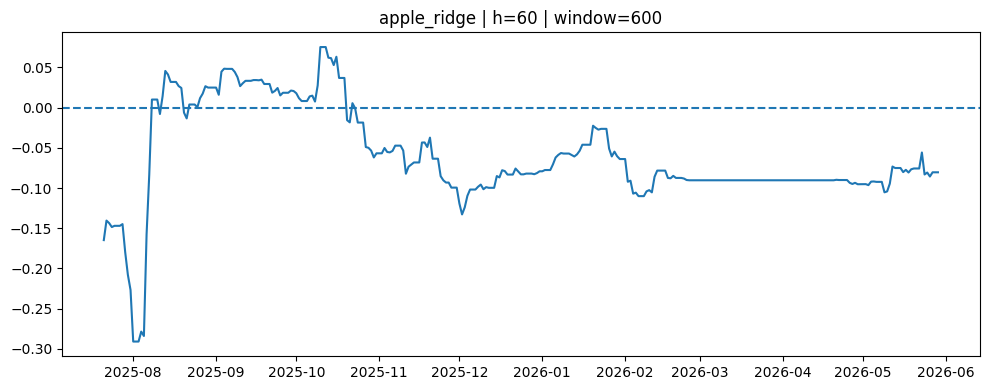

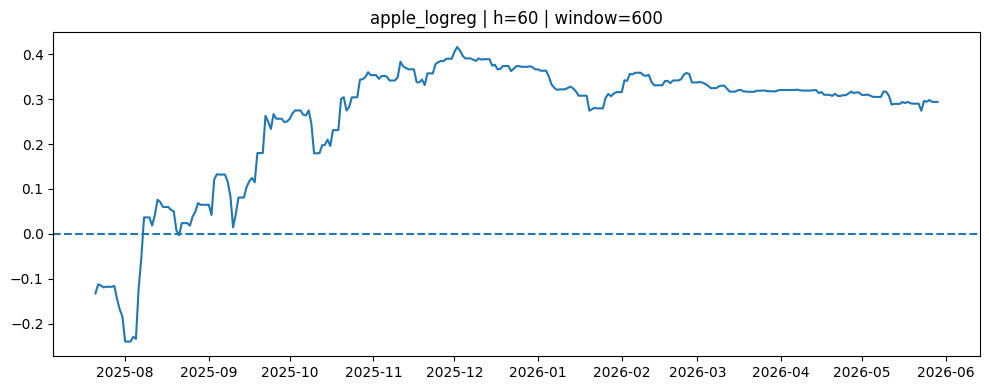

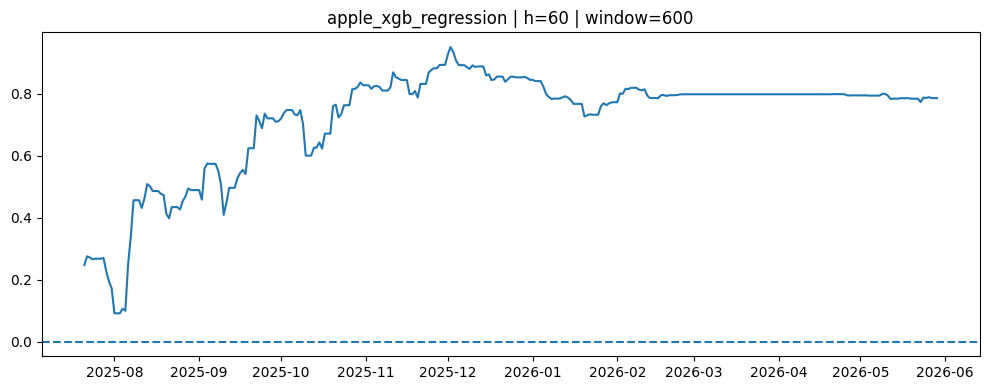

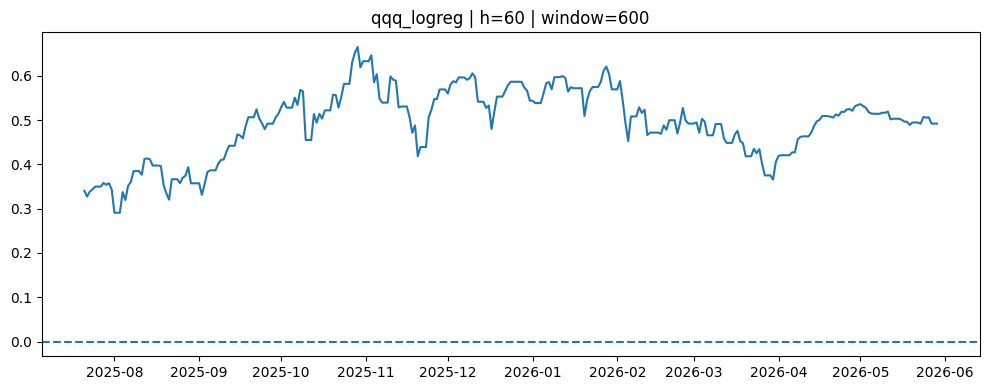

In [81]:
for h in [3, 5, 10, 30, 60]:
    window = max(60, 10 * h)
    df = pd.read_parquet(f"pnl_horizon_{h}.parquet")
    for col in df.columns:
        if col == "Date":
            continue
        rolling_sr = (
            df[col].rolling(window).mean()
            / df[col].rolling(window).std()
            * np.sqrt(252))
        plt.figure(figsize=(10, 4))
        plt.plot(df["Date"], rolling_sr)
        plt.axhline(0, linestyle="--")
        plt.title(
            f"{col} | h={h} | window={window}")
        plt.tight_layout()
        plt.show()

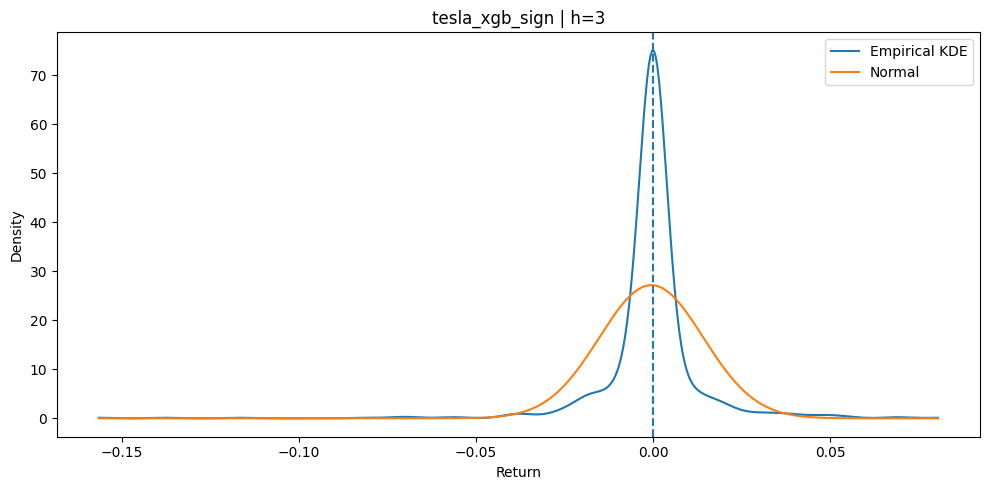

In [89]:
col = "tesla_xgb_sign"
rets = df.loc[:, col]
if isinstance(rets, pd.DataFrame):
    rets = rets.iloc[:, 0]
rets = rets.dropna().to_numpy()
mu = rets.mean()
sigma = rets.std(ddof=1)
x = np.linspace(rets.min(), rets.max(), 500)
kde = gaussian_kde(rets)
plt.figure(figsize=(10, 5))
plt.plot(x, kde(x), label="Empirical KDE")
plt.plot(x, norm.pdf(x, mu, sigma), label="Normal")
plt.axvline(0, linestyle="--")
plt.title(f"{col} | h=3")
plt.xlabel("Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()